
---

# Part A — Step 5: big cross-well period-1 (γ=4)

δ=0.7, γ=4, ω=1.525 — globally attracting cross-well loop. Scalar vs additive; coverage, rays, attractor overlay.

---


# Duffing Neural ODE — Step 5: the cross-well regime

New parameters, same physics: $\ddot{x} + \delta\dot{x} - x + x^3 = \gamma\cos\omega t$
with $\delta = 0.7$, $\gamma = 4$, $\omega = 1.525$. The drive is now 8× stronger than in
Steps 2–4 and the response is qualitatively different: instead of settling into one well,
the steady-state orbit **sweeps across both wells every drive period**.

Pre-characterization of this regime (reproduced in the tour below):

- the attractor spans roughly $x \in [-2.6, 2.6]$, $\dot{x} \in [-3.4, 3.4]$ — it
  straddles the barrier and both well bottoms;
- the strobe section (state sampled once per drive period) collapses to a **single
  point**: this is a **period-1 cross-well orbit**, not chaos — the largest Lyapunov
  exponent is $\approx -0.34\,/\mathrm{s}$, so nearby trajectories converge;
- every IC we tried lands on the **same** orbit — one globally attracting limit cycle.
  (The odd symmetry that gave Steps 2–4 their mirror-pair attractors now maps this orbit
  onto itself, shifted by half a period.)

Because the dynamics are contracting, pointwise rollout error remains a meaningful
metric at every horizon — no Lyapunov cutoff needed — and we additionally compare
**attractor geometry** (learned limit cycle vs true) as the long-run test.

Two models, identical to the Step-4 finalists, so the additivity result can be
re-tested in a harder regime:

| model | acceleration $\dot{x}_2$ | params |
|---|---|---|
| **scalar** | one MLP$(x, \dot{x}, \cos\omega t, \sin\omega t)$, 1 output | ~4.5k |
| **additive** | $f_\theta(x) + d_\theta(\dot{x}) + g_\theta(\cos\omega t, \sin\omega t)$ | ~3.5k |

Both hardwire $\dot{x}_1 = x_2$ (settled in Step 4). Predictions to falsify: additive
again extrapolates further along the rays and hands back the three force laws; the drive
subnet must now discover an amplitude-4 sinusoid; the restoring subnet must track the
cubic over a 3× wider range than before, so its tanh saturation ceiling should bite
closer to the data edge.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

jax.config.update('jax_enable_x64', True)

DELTA, GAMMA, OMEGA = 0.7, 4.0, 1.525
T_DRIVE = 2 * np.pi / OMEGA

def true_rhs(s, t):
    x, v = s
    return jnp.array([v, -DELTA * v + x - x**3 + GAMMA * jnp.cos(OMEGA * t)])

def rk4_step(f, s, t, dt):
    k1 = f(s, t)
    k2 = f(s + 0.5 * dt * k1, t + 0.5 * dt)
    k3 = f(s + 0.5 * dt * k2, t + 0.5 * dt)
    k4 = f(s + dt * k3, t + dt)
    return s + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def simulate(f, s0, t0, n_save, dt_save, substeps):
    dt = dt_save / substeps
    def sub(c, _):
        s, t = c
        return (rk4_step(f, s, t, dt), t + dt), None
    def save_step(carry, _):
        carry, _ = jax.lax.scan(sub, carry, None, length=substeps)
        return carry, carry[0]
    _, traj = jax.lax.scan(save_step, (s0, t0), None, length=n_save)
    return jnp.concatenate([s0[None], traj])

DT_INT, DT_SAVE = 0.005, 0.01
SUBS = int(round(DT_SAVE / DT_INT))

## 0 — Regime tour

One long trajectory: the time series, the steady-state phase portrait, and the strobe
section. The strobe is the periodicity detector — one dot = period-1, two dots =
period-2, dust = chaos.

attractor extent:  |x| <= 2.588   |xdot| <= 3.352


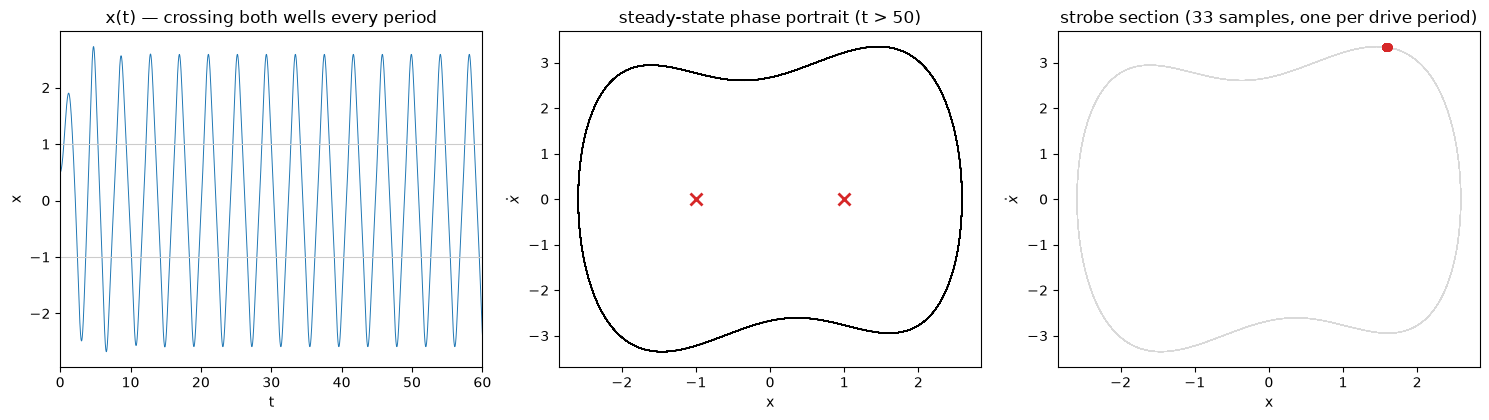

strobe scatter:  std x 1.07e-02   std xdot 2.53e-03   -> period-1


In [2]:
T_TOUR = 200.0
N_TOUR = int(round(T_TOUR / DT_SAVE))
tour = np.asarray(simulate(true_rhs, jnp.array([0.5, 0.0]), 0.0,
                           N_TOUR, DT_SAVE, SUBS))
t_tour = np.arange(N_TOUR + 1) * DT_SAVE
steady = tour[t_tour > 50.0]

EXT_X = float(np.abs(steady[:, 0]).max())
EXT_V = float(np.abs(steady[:, 1]).max())
print(f'attractor extent:  |x| <= {EXT_X:.3f}   |xdot| <= {EXT_V:.3f}')

strobe_idx = np.round(np.arange(15, int(T_TOUR / T_DRIVE)) * T_DRIVE
                      / DT_SAVE).astype(int)
strobe = tour[strobe_idx]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
a = ax[0]
a.plot(t_tour, tour[:, 0], lw=0.7)
a.axhline(1, color='0.8', lw=0.8)
a.axhline(-1, color='0.8', lw=0.8)
a.set_xlim(0, 60)
a.set_xlabel('t'); a.set_ylabel('x')
a.set_title('x(t) — crossing both wells every period')

a = ax[1]
a.plot(steady[:, 0], steady[:, 1], 'k', lw=0.8)
a.plot([-1, 1], [0, 0], 'x', color='tab:red', ms=8, mew=2)
a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')
a.set_title('steady-state phase portrait (t > 50)')

a = ax[2]
a.plot(steady[:, 0], steady[:, 1], color='0.85', lw=0.6, zorder=0)
a.plot(strobe[:, 0], strobe[:, 1], 'o', color='tab:red', ms=5)
a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')
a.set_title(f'strobe section ({len(strobe)} samples, one per drive period)')
plt.tight_layout(); plt.show()

print(f'strobe scatter:  std x {strobe[:, 0].std():.2e}'
      f'   std xdot {strobe[:, 1].std():.2e}   -> period-1')

## 1 — Training data, auto-scaled to the attractor

Same recipe as Steps 2–4 — a 9×7 grid of initial conditions, 20 s each — but the IC box
is sized from the measured attractor extent (80% of it) instead of the old hand-picked
$[\pm 0.75] \times [\pm 0.4]$, which would now sit deep inside the orbit.

In [3]:
T_END = 20.0
N_SAVE = int(round(T_END / DT_SAVE))
times = np.arange(N_SAVE + 1) * DT_SAVE

X0_LIM = round(0.8 * EXT_X, 1)
V0_LIM = round(0.8 * EXT_V, 1)
print(f'IC box: x0 in [-{X0_LIM}, {X0_LIM}]   xdot0 in [-{V0_LIM}, {V0_LIM}]')

ic_grid = np.stack(np.meshgrid(np.linspace(-X0_LIM, X0_LIM, 9),
                               np.linspace(-V0_LIM, V0_LIM, 7),
                               indexing='ij'), axis=-1).reshape(-1, 2)

sim_batch = jax.vmap(lambda s0: simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))
trajs = np.asarray(sim_batch(jnp.asarray(ic_grid)))
print('training trajectories:', trajs.shape)

IC box: x0 in [-2.1, 2.1]   xdot0 in [-2.7, 2.7]
training trajectories: (63, 2001, 2)


### Where the data lives

The coverage map from Step 3, recomputed for the new regime. In Steps 2–4 the data
concentrated on two thin single-well rings; here every trajectory funnels onto the one
big cross-well loop, so the dark ridge is a single fat ring with a transient web inside
it.

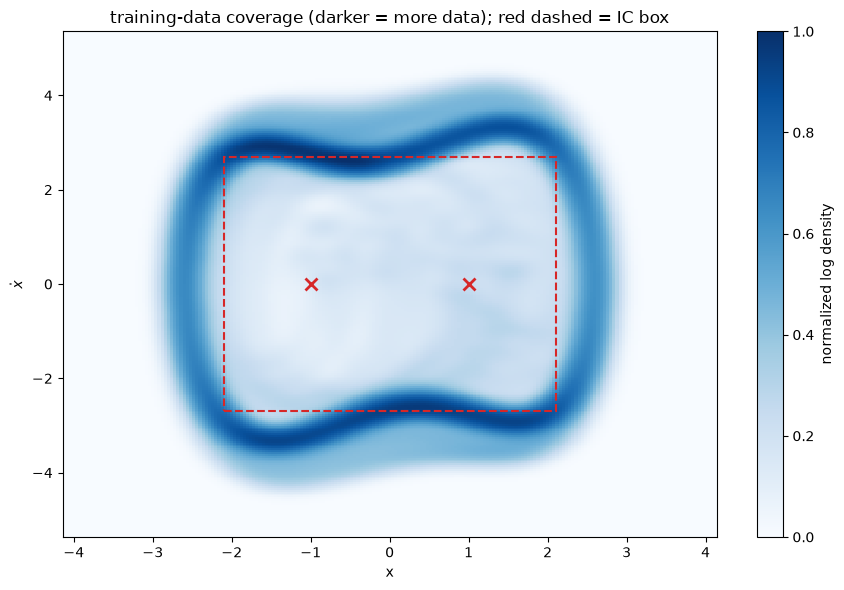

In [4]:
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Rectangle, Patch

pts = trajs[:, :-1, :].reshape(-1, 2)
BIN, SIG = 0.04, 0.16
XB = np.arange(-1.6 * EXT_X, 1.6 * EXT_X + 1e-9, BIN)
VB = np.arange(-1.6 * EXT_V, 1.6 * EXT_V + 1e-9, BIN)
H, _, _ = np.histogram2d(pts[:, 0], pts[:, 1], bins=[XB, VB])
D_log = np.log10(1.0 + gaussian_filter(H, SIG / BIN))
D_norm = D_log / D_log.max()
xc = 0.5 * (XB[:-1] + XB[1:])
vc = 0.5 * (VB[:-1] + VB[1:])

def coverage_at(x, v):
    i = np.clip(np.searchsorted(xc, x), 0, len(xc) - 1)
    j = np.clip(np.searchsorted(vc, v), 0, len(vc) - 1)
    return D_norm[i, j]

fig, a = plt.subplots(figsize=(9, 6))
pc = a.pcolormesh(XB, VB, D_norm.T, cmap='Blues', vmin=0, vmax=1,
                  rasterized=True)
a.add_patch(Rectangle((-X0_LIM, -V0_LIM), 2 * X0_LIM, 2 * V0_LIM,
                      fill=False, edgecolor='tab:red', ls='--', lw=1.5))
a.plot([-1, 1], [0, 0], 'x', color='tab:red', ms=8, mew=2)
a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')
a.set_title('training-data coverage (darker = more data);'
            ' red dashed = IC box')
fig.colorbar(pc, ax=a, label='normalized log density')
plt.tight_layout(); plt.show()

## 2 — The two models

In [5]:
def init_mlp(key, layers):
    params = []
    for n_in, n_out in zip(layers[:-1], layers[1:]):
        key, k = jax.random.split(key)
        W = jax.random.normal(k, (n_in, n_out)) * jnp.sqrt(1.0 / n_in)
        params.append((W, jnp.zeros(n_out)))
    return params

def mlp(params, u):
    h = u
    for W, b in params[:-1]:
        h = jnp.tanh(h @ W + b)
    W, b = params[-1]
    return h @ W + b

def make_input(s, t):
    return jnp.array([s[0], s[1], jnp.cos(OMEGA * t), jnp.sin(OMEGA * t)])

LAYERS_SCALAR = [4, 64, 64, 1]
def init_scalar(key):
    return init_mlp(key, LAYERS_SCALAR)
def rhs_scalar(params, s, t):
    a = mlp(params, make_input(s, t))[0]
    return jnp.array([s[1], a])

F_LAYERS = [1, 32, 32, 1]
D_LAYERS = [1, 32, 32, 1]
G_LAYERS = [2, 32, 32, 1]
N_F, N_D = len(F_LAYERS) - 1, len(D_LAYERS) - 1

def init_additive(key):
    kf, kd, kg = jax.random.split(key, 3)
    return (init_mlp(kf, F_LAYERS) + init_mlp(kd, D_LAYERS)
            + init_mlp(kg, G_LAYERS))

def additive_terms(params, s, t):
    pf = params[:N_F]
    pd = params[N_F:N_F + N_D]
    pg = params[N_F + N_D:]
    f = mlp(pf, jnp.array([s[0]]))[0]
    d = mlp(pd, jnp.array([s[1]]))[0]
    g = mlp(pg, jnp.array([jnp.cos(OMEGA * t), jnp.sin(OMEGA * t)]))[0]
    return f, d, g

def rhs_additive(params, s, t):
    f, d, g = additive_terms(params, s, t)
    return jnp.array([s[1], f + d + g])

for name, init in [('scalar', init_scalar), ('additive', init_additive)]:
    n = sum(W.size + b.size for W, b in init(jax.random.PRNGKey(0)))
    print(f'{name:9s} parameters: {n}')

scalar    parameters: 4545


additive  parameters: 3491


## 3 — Training

Same harness as Steps 3–4: one-step state-prediction MSE through one RK4 step,
`PRNGKey(0)` init, `PRNGKey(1)` minibatch stream, lr 1e-3 → 1e-4 at step 8000, 12000
steps, parameters cached to `params_cw_<tag>.npz` (delete the file to retrain). Loss
numbers run larger than in Steps 2–4 simply because the states are ~3× larger.

In [6]:
import os

s_now = jnp.asarray(trajs[:, :-1, :].reshape(-1, 2))
s_next = jnp.asarray(trajs[:, 1:, :].reshape(-1, 2))
t_now = jnp.asarray(np.tile(times[:-1], len(ic_grid)))
N_PAIRS = s_now.shape[0]
print('training pairs:', N_PAIRS)

def adam_update(params, grads, m, v, step, lr, b1=0.9, b2=0.999, eps=1e-8):
    m = jax.tree.map(lambda m_, g: b1 * m_ + (1 - b1) * g, m, grads)
    v = jax.tree.map(lambda v_, g: b2 * v_ + (1 - b2) * g * g, v, grads)
    mhat = jax.tree.map(lambda m_: m_ / (1 - b1 ** step), m)
    vhat = jax.tree.map(lambda v_: v_ / (1 - b2 ** step), v)
    new = jax.tree.map(lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
                       params, mhat, vhat)
    return new, m, v

BATCH = 16384
N_STEPS = 12000
EVAL_EVERY = 250

def train(rhs, init_fn, tag):
    def one_step(params, s, t):
        return rk4_step(lambda s_, t_: rhs(params, s_, t_), s, t, DT_SAVE)

    def loss_on(params, sb, snb, tb):
        pred = jax.vmap(lambda s, t: one_step(params, s, t))(sb, tb)
        return jnp.mean((pred - snb) ** 2)

    full_loss = jax.jit(lambda p: loss_on(p, s_now, s_next, t_now))

    cache = f'params_cw_{tag}.npz'
    if os.path.exists(cache):
        z = np.load(cache)
        n_layers = sum(1 for k in z.files if k.startswith('W'))
        params = [(jnp.asarray(z[f'W{i}']), jnp.asarray(z[f'b{i}']))
                  for i in range(n_layers)]
        print(f'[{tag}] loaded cached params from {cache}   '
              f'full loss {float(full_loss(params)):.3e}   '
              f'(delete the file to retrain)')
        return (params, z['hist_steps'], z['hist_loss'], full_loss,
                float(z['wall']))

    @jax.jit
    def train_step(params, m, v, step, lr, key):
        idx = jax.random.randint(key, (BATCH,), 0, N_PAIRS)
        loss, grads = jax.value_and_grad(loss_on)(params, s_now[idx],
                                                  s_next[idx], t_now[idx])
        params, m, v = adam_update(params, grads, m, v, step, lr)
        return params, m, v, loss

    params = init_fn(jax.random.PRNGKey(0))
    m = jax.tree.map(jnp.zeros_like, params)
    v = jax.tree.map(jnp.zeros_like, params)
    base_key = jax.random.PRNGKey(1)

    hist_steps, hist_loss = [], []
    t0 = time.time()
    for i in range(1, N_STEPS + 1):
        lr = 1e-3 if i <= 8000 else 1e-4
        params, m, v, _ = train_step(params, m, v, float(i), lr,
                                     jax.random.fold_in(base_key, i))
        if i == 1 or i % EVAL_EVERY == 0:
            fl = float(full_loss(params))
            hist_steps.append(i)
            hist_loss.append(fl)
            if i == 1 or i % 2000 == 0:
                print(f'[{tag}] step {i:6d}   lr {lr:.0e}   full loss {fl:.3e}')
    wall = time.time() - t0
    print(f'[{tag}] final full loss {hist_loss[-1]:.3e}   wall time {wall:.0f} s')
    np.savez(cache, hist_steps=np.array(hist_steps),
             hist_loss=np.array(hist_loss), wall=wall,
             **{f'W{i}': np.asarray(W) for i, (W, _) in enumerate(params)},
             **{f'b{i}': np.asarray(b) for i, (_, b) in enumerate(params)})
    return params, np.array(hist_steps), np.array(hist_loss), full_loss, wall

params_s, steps_s, loss_s, _, wall_s = train(rhs_scalar, init_scalar, 'scalar')
params_a, steps_a, loss_a, _, wall_a = train(rhs_additive, init_additive,
                                             'additive')

MODELS = [('scalar', rhs_scalar, params_s, 'tab:blue'),
          ('additive', rhs_additive, params_a, 'tab:green')]

training pairs: 126000


[scalar] loaded cached params from params_cw_scalar.npz   full loss 1.309e-08   (delete the file to retrain)


[additive] loaded cached params from params_cw_additive.npz   full loss 4.393e-09   (delete the file to retrain)


## 4 — Learning curves

Both models hardwire the velocity row, so the one-step losses are directly comparable
this time.

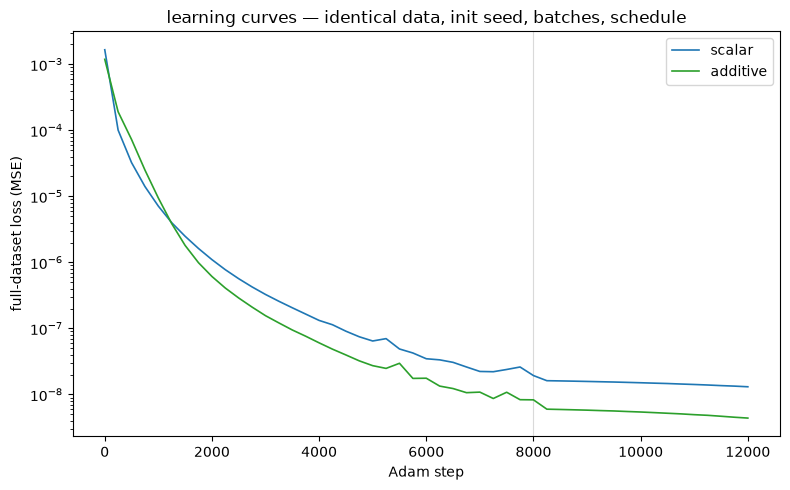

final loss   scalar 1.309e-08   additive 4.393e-09
wall time    scalar 133 s   additive 157 s


In [7]:
fig, a = plt.subplots(figsize=(8, 5))
for (tag, _, _, color), st, lo in [(MODELS[0], steps_s, loss_s),
                                   (MODELS[1], steps_a, loss_a)]:
    a.semilogy(st, lo, color=color, lw=1.2, label=tag)
a.axvline(8000, color='0.85', lw=0.8, zorder=0)
a.set_xlabel('Adam step')
a.set_ylabel('full-dataset loss (MSE)')
a.set_title('learning curves — identical data, init seed, batches, schedule')
a.legend()
plt.tight_layout(); plt.show()

print(f'final loss   scalar {loss_s[-1]:.3e}   additive {loss_a[-1]:.3e}')
print(f'wall time    scalar {wall_s:.0f} s   additive {wall_a:.0f} s')

## 5 — Accuracy: one-step errors and held-out ICs

One-step error over all 126k training pairs, then free 20 s rollouts from five held-out
interior ICs (the Step-2/3 held-out points, rescaled to the new box). "Locked" means the
rollout is still phase-aligned with the truth at the end: mean error over the final 5 s
below 1 (about a third of the orbit's radius). On a contracting periodic attractor
that is the pass/fail that replaces Step 3's wrong-well test.

In [8]:
def one_step_errors(rhs, params):
    f = lambda s, t: rk4_step(lambda s_, t_: rhs(params, s_, t_), s, t, DT_SAVE)
    pred = jax.vmap(f)(s_now, t_now)
    return np.asarray(jnp.linalg.norm(pred - s_next, axis=1))

for tag, rhs, p, _ in MODELS:
    e = one_step_errors(rhs, p)
    print(f'{tag:9s} one-step error   median {np.median(e):.2e}'
          f'   mean {e.mean():.2e}   max {e.max():.2e}')

FRACS = [(0.44, 0.42), (-0.81, -0.72), (0.07, -0.92), (0.93, 0.87),
         (-0.67, 0.0)]
INTERP_ICS = [(round(fx * X0_LIM, 2), round(fv * V0_LIM, 2))
              for fx, fv in FRACS]

LOCK_ERR = 1.0
lock_win = times[:-1] >= T_END - 5.0

def rollout_err(rhs, params, ic):
    s0 = jnp.array(ic)
    tru = np.asarray(simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))
    rol = np.asarray(simulate(lambda s, t: rhs(params, s, t),
                              s0, 0.0, N_SAVE, DT_SAVE, 1))
    err = np.linalg.norm(rol - tru, axis=1)
    locked = err[:-1][lock_win].mean() < LOCK_ERR
    return err.mean(), locked

print()
print('held-out IC rollouts (mean error over 20 s):')
print(f'{"IC":>16s} {"scalar":>12s} {"additive":>12s}   locked?')
for ic in INTERP_ICS:
    row, locks = [], []
    for tag, rhs, p, _ in MODELS:
        e, l = rollout_err(rhs, p, ic)
        row.append(e)
        locks.append(l)
    print(f'{str(ic):>16s} {row[0]:>12.2e} {row[1]:>12.2e}'
          f'   {locks[0]} / {locks[1]}')

scalar    one-step error   median 4.39e-05   mean 8.84e-05   max 4.42e-03
additive  one-step error   median 4.77e-05   mean 6.07e-05   max 2.00e-03

held-out IC rollouts (mean error over 20 s):
              IC       scalar     additive   locked?


    (0.92, 1.13)     4.02e-03     1.03e-03   True / True


   (-1.7, -1.94)     2.58e-02     1.14e-03   True / True


   (0.15, -2.48)     9.33e-03     1.35e-03   True / True


    (1.95, 2.35)     2.63e-03     1.31e-03   True / True


    (-1.41, 0.0)     7.92e-03     3.46e-03   True / True


## 6 — Extrapolation rays, with data coverage

The same two rays as Steps 2–4 ($\dot{x}_0 = 0$ sweeping $x_0$, and $x_0 = 0$ sweeping
$\dot{x}_0$), extended to 1.5× the attractor extent along $x_0$ and 2.5× along
$\dot{x}_0$ — far enough to watch each model's error finally turn upward. ▼ marks starts where the model has
lost phase lock by the end of the rollout. Every true trajectory here converges to the
same attractor, so the question is purely: how far outside the data can each model start
and still find its way onto the right orbit?

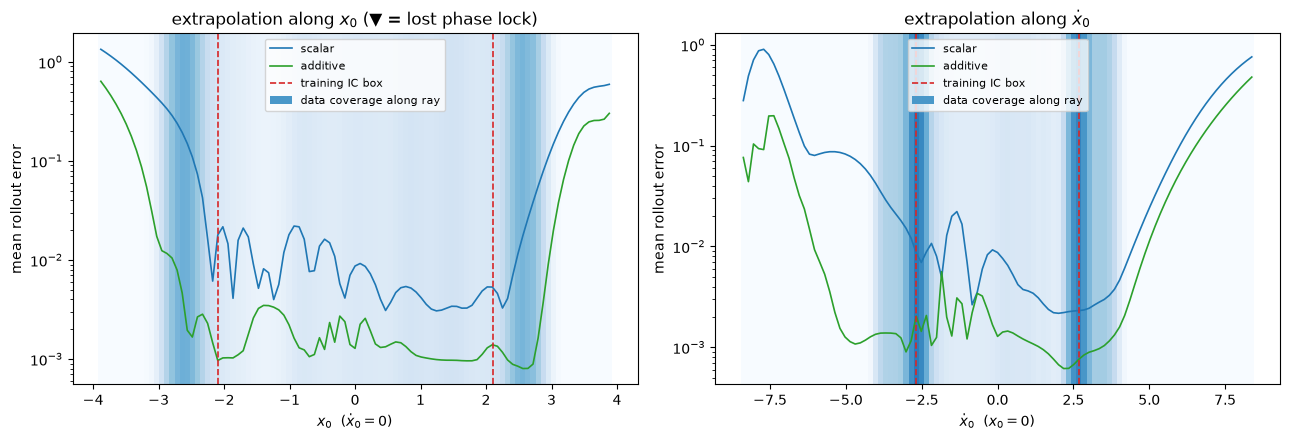

--- ray along x0 ---
  scalar    median err 1.49e-02   lost-lock starts: 0/101
  additive  median err 1.67e-03   lost-lock starts: 0/101
--- ray along v0 ---
  scalar    median err 2.44e-02   lost-lock starts: 0/101
  additive  median err 2.19e-03   lost-lock starts: 0/101


In [9]:
def ray_errors(rhs, params, ics):
    ics = jnp.asarray(ics)
    f = lambda s, t: rhs(params, s, t)
    tru = np.asarray(jax.vmap(
        lambda s0: simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))(ics))
    rol = np.asarray(jax.vmap(
        lambda s0: simulate(f, s0, 0.0, N_SAVE, DT_SAVE, 1))(ics))
    err = np.linalg.norm(rol - tru, axis=2)
    lost = err[:, :-1][:, lock_win].mean(axis=1) > LOCK_ERR
    return err.mean(axis=1), lost

x_ray = np.linspace(-1.5 * EXT_X, 1.5 * EXT_X, 101)
v_ray = np.linspace(-2.5 * EXT_V, 2.5 * EXT_V, 101)
rays = {'x': np.stack([x_ray, np.zeros_like(x_ray)], axis=1),
        'v': np.stack([np.zeros_like(v_ray), v_ray], axis=1)}
res = {tag: {k: ray_errors(rhs, p, ics) for k, ics in rays.items()}
       for tag, rhs, p, _ in MODELS}

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a, key, ray, lim, name in [
        (ax[0], 'x', x_ray, X0_LIM, '$x_0$  ($\\dot{x}_0 = 0$)'),
        (ax[1], 'v', v_ray, V0_LIM, '$\\dot{x}_0$  ($x_0 = 0$)')]:
    cov = coverage_at(rays[key][:, 0], rays[key][:, 1])
    dr = ray[1] - ray[0]
    for xi, ci in zip(ray, cov):
        a.axvspan(xi - dr / 2, xi + dr / 2,
                  color=plt.cm.Blues(0.75 * ci), lw=0, zorder=0)
    for tag, _, _, color in MODELS:
        err, lost = res[tag][key]
        a.semilogy(ray, err, color=color, lw=1.2, label=tag)
        a.semilogy(ray[lost], err[lost], 'v', color=color, ms=5)
    a.axvline(-lim, color='tab:red', lw=1.2, ls='--')
    a.axvline(lim, color='tab:red', lw=1.2, ls='--', label='training IC box')
    a.set_xlabel(name); a.set_ylabel('mean rollout error')
    handles, _ = a.get_legend_handles_labels()
    handles.append(Patch(facecolor=plt.cm.Blues(0.6),
                         label='data coverage along ray'))
    a.legend(handles=handles, loc='upper center', fontsize=8)
ax[0].set_title('extrapolation along $x_0$ (▼ = lost phase lock)')
ax[1].set_title('extrapolation along $\\dot{x}_0$')
plt.tight_layout(); plt.show()

for key, ray in [('x', x_ray), ('v', v_ray)]:
    print(f'--- ray along {key}0 ---')
    for tag, *_ in MODELS:
        err, lost = res[tag][key]
        print(f'  {tag:9s} median err {np.median(err):.2e}'
              f'   lost-lock starts: {int(lost.sum())}/{len(ray)}')

## 7 — The long-run test: learned attractor vs true

Two views. Left: short-horizon tracking — error vs time for a rollout from a held-out
IC, both models. Right: the geometry test — run each learned model for 200 s, discard
the transient, and overlay its limit cycle and strobe point on the truth. A model can
drift in phase yet still be dynamically right; this plot shows whether the *orbit
itself* — shape, size, strobe location — was learned.

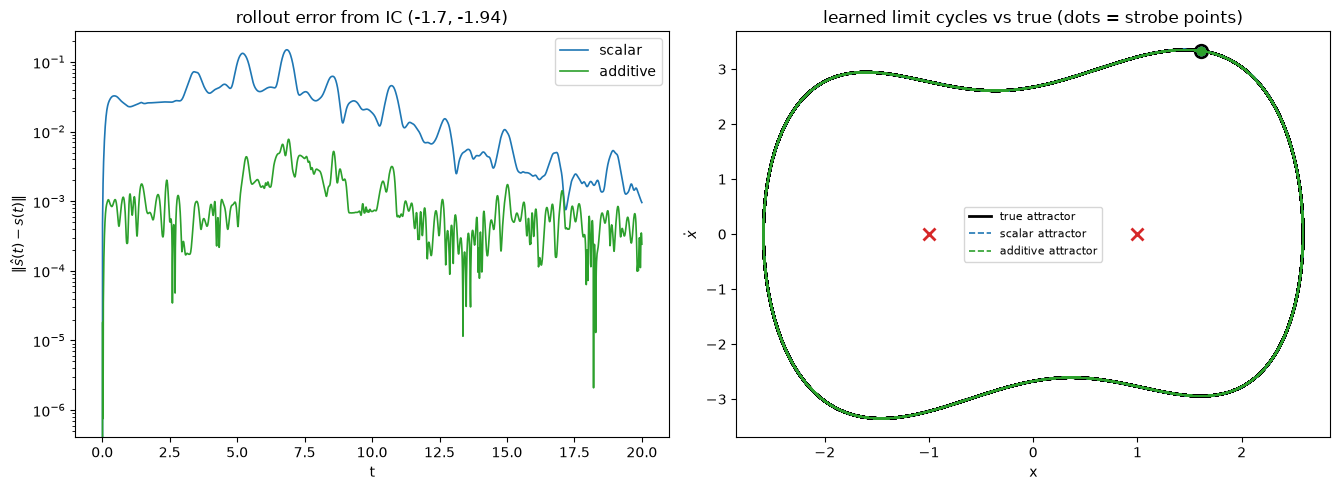

scalar    strobe-point offset from truth: 2.84e-04   strobe scatter: [0.01350653 0.00318794]


additive  strobe-point offset from truth: 6.78e-04   strobe scatter: [0.01350285 0.00319032]


In [10]:
IC_SHOW = INTERP_ICS[1]
s0 = jnp.array(IC_SHOW)
tru = np.asarray(simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))

fig, ax = plt.subplots(1, 2, figsize=(13.5, 5))
a = ax[0]
for tag, rhs, p, color in MODELS:
    rol = np.asarray(simulate(lambda s, t: rhs(p, s, t),
                              s0, 0.0, N_SAVE, DT_SAVE, 1))
    a.semilogy(times, np.linalg.norm(rol - tru, axis=1), color=color,
               lw=1.2, label=tag)
a.set_xlabel('t'); a.set_ylabel(r'$\|\hat{s}(t) - s(t)\|$')
a.set_title(f'rollout error from IC {IC_SHOW}')
a.legend()

a = ax[1]
a.plot(steady[:, 0], steady[:, 1], 'k', lw=2.0, label='true attractor')
a.plot(strobe[-1, 0], strobe[-1, 1], 'o', color='k', ms=9, mfc='none',
       mew=2)
for tag, rhs, p, color in MODELS:
    long = np.asarray(simulate(lambda s, t: rhs(p, s, t),
                               jnp.array([0.5, 0.0]), 0.0,
                               N_TOUR, DT_SAVE, 1))
    lsteady = long[t_tour > 50.0]
    lstrobe = long[strobe_idx]
    a.plot(lsteady[:, 0], lsteady[:, 1], '--', color=color, lw=1.2,
           label=f'{tag} attractor')
    a.plot(lstrobe[-1, 0], lstrobe[-1, 1], 'o', color=color, ms=6)
a.plot([-1, 1], [0, 0], 'x', color='tab:red', ms=8, mew=2)
a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')
a.set_title('learned limit cycles vs true (dots = strobe points)')
a.legend(fontsize=8)
plt.tight_layout(); plt.show()

for tag, rhs, p, _ in MODELS:
    long = np.asarray(simulate(lambda s, t: rhs(p, s, t),
                               jnp.array([0.5, 0.0]), 0.0,
                               N_TOUR, DT_SAVE, 1))
    lstrobe = long[strobe_idx]
    dstrobe = np.linalg.norm(lstrobe[-1] - strobe[-1])
    print(f'{tag:9s} strobe-point offset from truth: {dstrobe:.2e}'
          f'   strobe scatter: {lstrobe[-20:].std(axis=0)}')

## 8 — The learned forces, term by term

The additive model's payoff, exactly as in Step 4: each subnet against the law it
should have discovered — $f(x) = x - x^3$, $d(\dot{x}) = -\delta\dot{x}$ with
$\delta = 0.7$, $g = \gamma\cos\omega t$ with $\gamma = 4$. Same gauge fix (constants
can shuttle between terms without changing predictions): shift $g$ to zero mean over the
drive cycle, shift $d$ so $d(0) = 0$, absorb both into $f$.

The stakes are higher for $f_\theta$ than in Step 4: the data now reaches
$|x| \approx 2.9$, where the true restoring force is $\approx 21$ — the cubic's bend is
no longer a far-field problem, it is inside the data.

gauge constants:  mean(g) = +0.0570   d(0) = +0.2309   (moved into f)


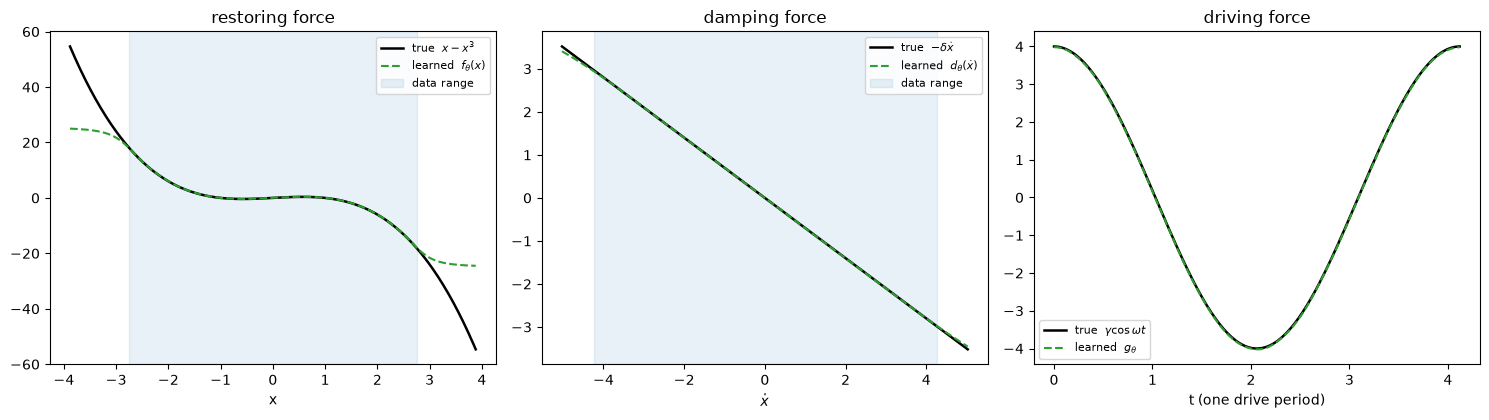

max |f error|   in data range 1.74e-01   at edges of plot: 3.01e+01
max |d error|   in data range 2.16e-02
max |g error|   2.97e-02


In [11]:
term_f = jax.vmap(lambda x: additive_terms(params_a,
                  jnp.array([x, 0.0]), 0.0)[0])
term_d = jax.vmap(lambda v: additive_terms(params_a,
                  jnp.array([0.0, v]), 0.0)[1])

t_cycle = np.linspace(0.0, T_DRIVE, 200)
term_g = jax.vmap(lambda t: additive_terms(params_a,
                  jnp.array([0.0, 0.0]), t)[2])

g_vals = np.asarray(term_g(jnp.asarray(t_cycle)))
c_g = g_vals.mean()
c_d = float(term_d(jnp.array([0.0]))[0])
print(f'gauge constants:  mean(g) = {c_g:+.4f}   d(0) = {c_d:+.4f}'
      f'   (moved into f)')

x_plot = np.linspace(-1.5 * EXT_X, 1.5 * EXT_X, 400)
v_plot = np.linspace(-1.5 * EXT_V, 1.5 * EXT_V, 400)
f_vals = np.asarray(term_f(jnp.asarray(x_plot))) + c_g + c_d
d_vals = np.asarray(term_d(jnp.asarray(v_plot))) - c_d
g_tilde = g_vals - c_g

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
a = ax[0]
a.plot(x_plot, x_plot - x_plot**3, 'k', lw=1.8, label='true  $x - x^3$')
a.plot(x_plot, f_vals, '--', color='tab:green', lw=1.5,
       label=r'learned  $f_\theta(x)$')
a.axvspan(pts[:, 0].min(), pts[:, 0].max(), color='tab:blue', alpha=0.10,
          label='data range')
a.set_xlabel('x'); a.set_title('restoring force')
a.legend(fontsize=8)

a = ax[1]
a.plot(v_plot, -DELTA * v_plot, 'k', lw=1.8,
       label=r'true  $-\delta\dot{x}$')
a.plot(v_plot, d_vals, '--', color='tab:green', lw=1.5,
       label=r'learned  $d_\theta(\dot{x})$')
a.axvspan(pts[:, 1].min(), pts[:, 1].max(), color='tab:blue', alpha=0.10,
          label='data range')
a.set_xlabel(r'$\dot{x}$'); a.set_title('damping force')
a.legend(fontsize=8)

a = ax[2]
a.plot(t_cycle, GAMMA * np.cos(OMEGA * t_cycle), 'k', lw=1.8,
       label=r'true  $\gamma\cos\omega t$')
a.plot(t_cycle, g_tilde, '--', color='tab:green', lw=1.5,
       label=r'learned  $g_\theta$')
a.set_xlabel('t (one drive period)'); a.set_title('driving force')
a.legend(fontsize=8)
plt.tight_layout(); plt.show()

in_x = (x_plot > pts[:, 0].min()) & (x_plot < pts[:, 0].max())
in_v = (v_plot > pts[:, 1].min()) & (v_plot < pts[:, 1].max())
f_err = np.abs(f_vals - (x_plot - x_plot**3))
print(f'max |f error|   in data range {f_err[in_x].max():.2e}'
      f'   at edges of plot: {f_err[[0, -1]].max():.2e}')
print(f'max |d error|   in data range {np.abs(d_vals + DELTA * v_plot)[in_v].max():.2e}')
print(f'max |g error|   {np.abs(g_tilde - GAMMA * np.cos(OMEGA * t_cycle)).max():.2e}')

## What this rung settles — and what it sets up

Things to read off the results above:

1. **Does additivity survive the regime change?** Step 4's result — additive extrapolates
   much further than the black box — was earned in a gentle single-well regime. The ray
   plot and lost-lock counts here re-test it where the drive is 8× stronger and the data
   range is 3× wider.
2. **The forces at scale**: the drive subnet must produce an amplitude-4 sinusoid, the
   damping subnet a slope-0.7 line over $|\dot{x}| \lesssim 3.4$, and the restoring
   subnet the cubic over $|x| \lesssim 2.9$ — where the cubic's curvature is squarely
   inside the data, so the in-range fit itself now stresses the tanh basis, not just the
   tails.
3. **The attractor overlay** is the new long-run metric: on a globally attracting
   period-1 orbit, the right question after the transient is whether the learned limit
   cycle has the true shape and strobe point, not whether every timestep matches.

Next rungs from here: the polynomial skeleton
$f_\theta(x) = c_1 x + c_3 x^3 + \text{MLP}$ (the fix both regimes' $f$ panels ask for);
then parameters that actually break periodicity — a chaotic set (e.g. the classic
$\delta = 0.3$, $\gamma = 0.5$, $\omega = 1.2$), where the strobe section turns to dust
and evaluation must go fully statistical.


---

# Part B — Step 6a: period-8 (freshly doubled)

δ=0.7, γ=3.175, ω=2.425. Exact-strobe periodicity tables applied to the learned models.

---


# Duffing Neural ODE — Step 6a: the period-8 cross-well regime

$\delta = 0.7$, $\gamma = 3.175$, $\omega = 2.425$. Pre-characterization on our
integrator (reproduced in the tour below):

- a **genuine period-8 orbit**: the strobe returns to itself after exactly 8 drive
  periods (residual $\sim 5\times10^{-9}$), and never sooner;
- the 8 strobe points sit in **4 tight pairs** only $\approx 0.02$ apart — this regime
  is freshly period-doubled from period-4, so a learned model must resolve
  0.02-scale structure in the strobe map to reproduce the true period instead of
  collapsing back to period-4;
- cross-well, $|x| \lesssim 1.46$, $|\dot{x}| \lesssim 1.69$; contraction is weak
  ($\lambda \approx -0.02\,/\mathrm{s}$, e-fold time $\sim 60$ s), so transients are
  long and every 20 s training trajectory is mostly transient — fine for one-step
  vector-field learning, but the long-run tests below use exact strobing after a long
  settle;
- odd symmetry gives a **mirror-twin** orbit ($x \to -x$, $\dot{x} \to -\dot{x}$,
  $t \to t + T/2$); some ICs land on one twin, some on the other.

Same two models and training process as Step 5 (scalar black box vs additive
$f_\theta(x) + d_\theta(\dot{x}) + g_\theta(\cos\omega t, \sin\omega t)$, both with
$\dot{x}_1 = x_2$ hardwired). The new headline metric: apply the strobe periodicity
test **to the learned models** — do they hold the period-8 structure, or do they lock
onto the wrong rung of the doubling cascade?

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

jax.config.update('jax_enable_x64', True)

DELTA, GAMMA, OMEGA = 0.7, 3.175, 2.425
T_DRIVE = 2 * np.pi / OMEGA
PERIOD_N = 8
ATTRACTOR_IC = (0.5, 0.0)
SECOND_IC = None
TAG = 'p8'

def true_rhs(s, t):
    x, v = s
    return jnp.array([v, -DELTA * v + x - x**3 + GAMMA * jnp.cos(OMEGA * t)])

def rk4_step(f, s, t, dt):
    k1 = f(s, t)
    k2 = f(s + 0.5 * dt * k1, t + 0.5 * dt)
    k3 = f(s + 0.5 * dt * k2, t + 0.5 * dt)
    k4 = f(s + dt * k3, t + dt)
    return s + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def simulate(f, s0, t0, n_save, dt_save, substeps):
    dt = dt_save / substeps
    def sub(c, _):
        s, t = c
        return (rk4_step(f, s, t, dt), t + dt), None
    def save_step(carry, _):
        carry, _ = jax.lax.scan(sub, carry, None, length=substeps)
        return carry, carry[0]
    _, traj = jax.lax.scan(save_step, (s0, t0), None, length=n_save)
    return jnp.concatenate([s0[None], traj])

DT_INT, DT_SAVE = 0.005, 0.01
SUBS = int(round(DT_SAVE / DT_INT))

# exact-strobe machinery: save step locked to T_DRIVE/SPP so strobe samples land
# exactly on drive-period multiples (a 0.01-grid strobe smears points by ~1e-2,
# which is the same size as the structure we need to resolve)
SPP = 64
DT_STROBE = T_DRIVE / SPP

def strobe_run(f, s0, n_per, substeps):
    traj = np.asarray(simulate(f, jnp.array(s0), 0.0, n_per * SPP,
                               DT_STROBE, substeps))
    return traj, traj[::SPP]

def period_table(sp, ms=(1, 2, 3, 4, 6, 8, 12)):
    for m in ms:
        d = np.linalg.norm(sp[m:] - sp[:-m], axis=1).max()
        marker = '  <-- period' if d < 1e-6 else ''
        print(f'   m={m:2d}   max |s(k+m) - s(k)| = {d:.2e}{marker}')

## 0 — Regime tour

Dense trajectory, steady-state phase portrait (one full $n T$ orbit segment), and the
exact strobe section with the periodicity table: the residual
$\max_k \|s(k{+}m) - s(k)\|$ over late strobes drops to integrator precision exactly at
the true period multiple.

attractor extent:  |x| <= 1.463   |xdot| <= 1.691
strobe periodicity from IC (0.5, 0.0) (last 80 of 480 periods):
   m= 1   max |s(k+m) - s(k)| = 5.14e-01
   m= 2   max |s(k+m) - s(k)| = 1.31e-01
   m= 3   max |s(k+m) - s(k)| = 5.07e-01
   m= 4   max |s(k+m) - s(k)| = 1.77e-02
   m= 6   max |s(k+m) - s(k)| = 1.31e-01
   m= 8   max |s(k+m) - s(k)| = 2.58e-09  <-- period
   m=12   max |s(k+m) - s(k)| = 1.77e-02


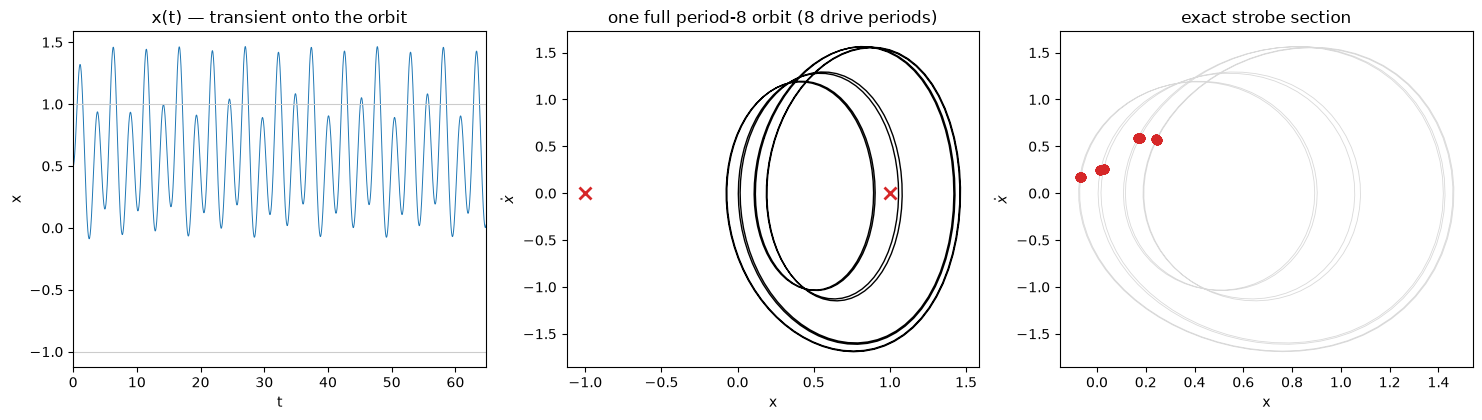

In [2]:
N_SETTLE, N_MEAS = 400, 80
tour_full, tour_sp = strobe_run(true_rhs, ATTRACTOR_IC,
                                N_SETTLE + N_MEAS, 4)
steady_tr = tour_full[N_SETTLE * SPP:]
sp_true = tour_sp[N_SETTLE:]
orbit = tour_full[N_SETTLE * SPP:(N_SETTLE + PERIOD_N) * SPP + 1]

EXT_X = float(np.abs(steady_tr[:, 0]).max())
EXT_V = float(np.abs(steady_tr[:, 1]).max())
print(f'attractor extent:  |x| <= {EXT_X:.3f}   |xdot| <= {EXT_V:.3f}')
print(f'strobe periodicity from IC {ATTRACTOR_IC} '
      f'(last {N_MEAS} of {N_SETTLE + N_MEAS} periods):')
period_table(sp_true)

if SECOND_IC is not None:
    chaos_full, chaos_sp_all = strobe_run(true_rhs, SECOND_IC,
                                          N_SETTLE + N_MEAS * 4, 4)
    chaos_sp = chaos_sp_all[N_SETTLE:]
    print(f'strobe periodicity from IC {SECOND_IC}:')
    period_table(chaos_sp)

t_dense = np.arange(len(tour_full)) * DT_STROBE

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
a = ax[0]
a.plot(t_dense, tour_full[:, 0], lw=0.7)
a.axhline(1, color='0.8', lw=0.8)
a.axhline(-1, color='0.8', lw=0.8)
a.set_xlim(0, 25 * T_DRIVE)
a.set_xlabel('t'); a.set_ylabel('x')
a.set_title('x(t) — transient onto the orbit')

a = ax[1]
a.plot(orbit[:, 0], orbit[:, 1], 'k', lw=1.0)
a.plot([-1, 1], [0, 0], 'x', color='tab:red', ms=8, mew=2)
a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')
a.set_title(f'one full period-{PERIOD_N} orbit ({PERIOD_N} drive periods)')

a = ax[2]
a.plot(orbit[:, 0], orbit[:, 1], color='0.85', lw=0.6, zorder=0)
a.plot(sp_true[:, 0], sp_true[:, 1], 'o', color='tab:red', ms=6,
       label=f'period-{PERIOD_N} strobe')
if SECOND_IC is not None:
    a.plot(chaos_sp[:, 0], chaos_sp[:, 1], '.', color='0.4', ms=2.5,
           label='chaotic-set strobe (coexisting)')
    a.legend(fontsize=8)
a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')
a.set_title('exact strobe section')
plt.tight_layout(); plt.show()

## 1 — Training data, auto-scaled to the attractor

Same recipe as Step 5: 9×7 IC grid at 80% of the measured extent, 20 s per
trajectory. Contraction is weak here, so these trajectories are mostly transient —
which is exactly what one-step vector-field training wants: broad phase-space
coverage, not one settled orbit.

In [3]:
T_END = 20.0
N_SAVE = int(round(T_END / DT_SAVE))
times = np.arange(N_SAVE + 1) * DT_SAVE

X0_LIM = round(0.8 * EXT_X, 1)
V0_LIM = round(0.8 * EXT_V, 1)
print(f'IC box: x0 in [-{X0_LIM}, {X0_LIM}]   xdot0 in [-{V0_LIM}, {V0_LIM}]')

ic_grid = np.stack(np.meshgrid(np.linspace(-X0_LIM, X0_LIM, 9),
                               np.linspace(-V0_LIM, V0_LIM, 7),
                               indexing='ij'), axis=-1).reshape(-1, 2)

sim_batch = jax.vmap(lambda s0: simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))
trajs = np.asarray(sim_batch(jnp.asarray(ic_grid)))
print('training trajectories:', trajs.shape)

IC box: x0 in [-1.2, 1.2]   xdot0 in [-1.4, 1.4]
training trajectories: (63, 2001, 2)


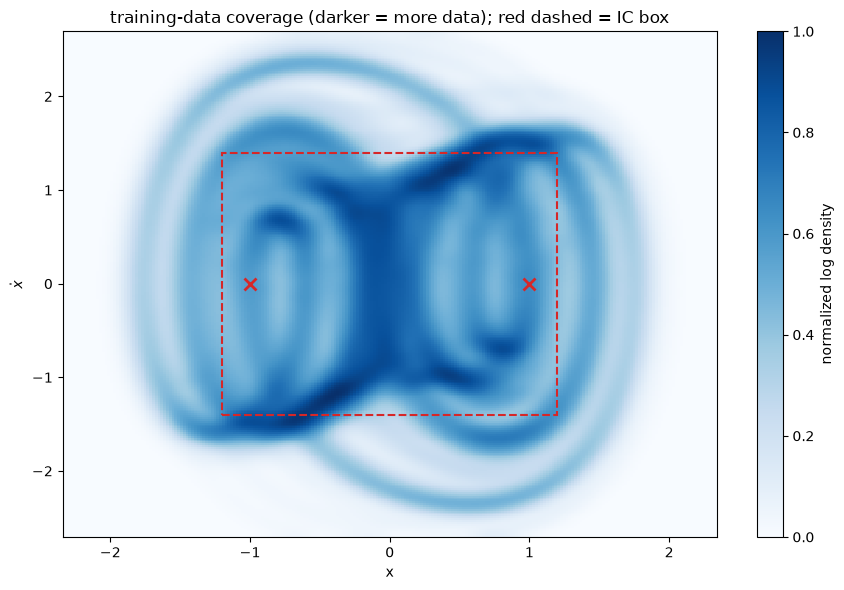

In [4]:
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Rectangle, Patch

pts = trajs[:, :-1, :].reshape(-1, 2)
BIN, SIG = 0.02, 0.08
XB = np.arange(-1.6 * EXT_X, 1.6 * EXT_X + 1e-9, BIN)
VB = np.arange(-1.6 * EXT_V, 1.6 * EXT_V + 1e-9, BIN)
H, _, _ = np.histogram2d(pts[:, 0], pts[:, 1], bins=[XB, VB])
D_log = np.log10(1.0 + gaussian_filter(H, SIG / BIN))
D_norm = D_log / D_log.max()
xc = 0.5 * (XB[:-1] + XB[1:])
vc = 0.5 * (VB[:-1] + VB[1:])

def coverage_at(x, v):
    i = np.clip(np.searchsorted(xc, x), 0, len(xc) - 1)
    j = np.clip(np.searchsorted(vc, v), 0, len(vc) - 1)
    return D_norm[i, j]

fig, a = plt.subplots(figsize=(9, 6))
pc = a.pcolormesh(XB, VB, D_norm.T, cmap='Blues', vmin=0, vmax=1,
                  rasterized=True)
a.add_patch(Rectangle((-X0_LIM, -V0_LIM), 2 * X0_LIM, 2 * V0_LIM,
                      fill=False, edgecolor='tab:red', ls='--', lw=1.5))
a.plot([-1, 1], [0, 0], 'x', color='tab:red', ms=8, mew=2)
a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')
a.set_title('training-data coverage (darker = more data);'
            ' red dashed = IC box')
fig.colorbar(pc, ax=a, label='normalized log density')
plt.tight_layout(); plt.show()

## 2 — The two models

In [5]:
def init_mlp(key, layers):
    params = []
    for n_in, n_out in zip(layers[:-1], layers[1:]):
        key, k = jax.random.split(key)
        W = jax.random.normal(k, (n_in, n_out)) * jnp.sqrt(1.0 / n_in)
        params.append((W, jnp.zeros(n_out)))
    return params

def mlp(params, u):
    h = u
    for W, b in params[:-1]:
        h = jnp.tanh(h @ W + b)
    W, b = params[-1]
    return h @ W + b

def make_input(s, t):
    return jnp.array([s[0], s[1], jnp.cos(OMEGA * t), jnp.sin(OMEGA * t)])

LAYERS_SCALAR = [4, 64, 64, 1]
def init_scalar(key):
    return init_mlp(key, LAYERS_SCALAR)
def rhs_scalar(params, s, t):
    a = mlp(params, make_input(s, t))[0]
    return jnp.array([s[1], a])

F_LAYERS = [1, 32, 32, 1]
D_LAYERS = [1, 32, 32, 1]
G_LAYERS = [2, 32, 32, 1]
N_F, N_D = len(F_LAYERS) - 1, len(D_LAYERS) - 1

def init_additive(key):
    kf, kd, kg = jax.random.split(key, 3)
    return (init_mlp(kf, F_LAYERS) + init_mlp(kd, D_LAYERS)
            + init_mlp(kg, G_LAYERS))

def additive_terms(params, s, t):
    pf = params[:N_F]
    pd = params[N_F:N_F + N_D]
    pg = params[N_F + N_D:]
    f = mlp(pf, jnp.array([s[0]]))[0]
    d = mlp(pd, jnp.array([s[1]]))[0]
    g = mlp(pg, jnp.array([jnp.cos(OMEGA * t), jnp.sin(OMEGA * t)]))[0]
    return f, d, g

def rhs_additive(params, s, t):
    f, d, g = additive_terms(params, s, t)
    return jnp.array([s[1], f + d + g])

for name, init in [('scalar', init_scalar), ('additive', init_additive)]:
    n = sum(W.size + b.size for W, b in init(jax.random.PRNGKey(0)))
    print(f'{name:9s} parameters: {n}')

scalar    parameters: 4545


additive  parameters: 3491


## 3 — Training

Identical harness to Step 5; caches `params_<tag>_<model>.npz` (delete to
retrain).

In [6]:
import os

s_now = jnp.asarray(trajs[:, :-1, :].reshape(-1, 2))
s_next = jnp.asarray(trajs[:, 1:, :].reshape(-1, 2))
t_now = jnp.asarray(np.tile(times[:-1], len(ic_grid)))
N_PAIRS = s_now.shape[0]
print('training pairs:', N_PAIRS)

def adam_update(params, grads, m, v, step, lr, b1=0.9, b2=0.999, eps=1e-8):
    m = jax.tree.map(lambda m_, g: b1 * m_ + (1 - b1) * g, m, grads)
    v = jax.tree.map(lambda v_, g: b2 * v_ + (1 - b2) * g * g, v, grads)
    mhat = jax.tree.map(lambda m_: m_ / (1 - b1 ** step), m)
    vhat = jax.tree.map(lambda v_: v_ / (1 - b2 ** step), v)
    new = jax.tree.map(lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
                       params, mhat, vhat)
    return new, m, v

BATCH = 16384
N_STEPS = 12000
EVAL_EVERY = 250

def train(rhs, init_fn, model_tag):
    def one_step(params, s, t):
        return rk4_step(lambda s_, t_: rhs(params, s_, t_), s, t, DT_SAVE)

    def loss_on(params, sb, snb, tb):
        pred = jax.vmap(lambda s, t: one_step(params, s, t))(sb, tb)
        return jnp.mean((pred - snb) ** 2)

    full_loss = jax.jit(lambda p: loss_on(p, s_now, s_next, t_now))

    cache = f'params_{TAG}_{model_tag}.npz'
    if os.path.exists(cache):
        z = np.load(cache)
        n_layers = sum(1 for k in z.files if k.startswith('W'))
        params = [(jnp.asarray(z[f'W{i}']), jnp.asarray(z[f'b{i}']))
                  for i in range(n_layers)]
        print(f'[{model_tag}] loaded cached params from {cache}   '
              f'full loss {float(full_loss(params)):.3e}   '
              f'(delete the file to retrain)')
        return (params, z['hist_steps'], z['hist_loss'], full_loss,
                float(z['wall']))

    @jax.jit
    def train_step(params, m, v, step, lr, key):
        idx = jax.random.randint(key, (BATCH,), 0, N_PAIRS)
        loss, grads = jax.value_and_grad(loss_on)(params, s_now[idx],
                                                  s_next[idx], t_now[idx])
        params, m, v = adam_update(params, grads, m, v, step, lr)
        return params, m, v, loss

    params = init_fn(jax.random.PRNGKey(0))
    m = jax.tree.map(jnp.zeros_like, params)
    v = jax.tree.map(jnp.zeros_like, params)
    base_key = jax.random.PRNGKey(1)

    hist_steps, hist_loss = [], []
    t0 = time.time()
    for i in range(1, N_STEPS + 1):
        lr = 1e-3 if i <= 8000 else 1e-4
        params, m, v, _ = train_step(params, m, v, float(i), lr,
                                     jax.random.fold_in(base_key, i))
        if i == 1 or i % EVAL_EVERY == 0:
            fl = float(full_loss(params))
            hist_steps.append(i)
            hist_loss.append(fl)
            if i == 1 or i % 2000 == 0:
                print(f'[{model_tag}] step {i:6d}   lr {lr:.0e}'
                      f'   full loss {fl:.3e}')
    wall = time.time() - t0
    print(f'[{model_tag}] final full loss {hist_loss[-1]:.3e}'
          f'   wall time {wall:.0f} s')
    np.savez(cache, hist_steps=np.array(hist_steps),
             hist_loss=np.array(hist_loss), wall=wall,
             **{f'W{i}': np.asarray(Wt) for i, (Wt, _) in enumerate(params)},
             **{f'b{i}': np.asarray(bt) for i, (_, bt) in enumerate(params)})
    return params, np.array(hist_steps), np.array(hist_loss), full_loss, wall

params_s, steps_s, loss_s, _, wall_s = train(rhs_scalar, init_scalar, 'scalar')
params_a, steps_a, loss_a, _, wall_a = train(rhs_additive, init_additive,
                                             'additive')

MODELS = [('scalar', rhs_scalar, params_s, 'tab:blue'),
          ('additive', rhs_additive, params_a, 'tab:green')]

training pairs: 126000


[scalar] step      1   lr 1e-03   full loss 2.825e-04


[scalar] step   2000   lr 1e-03   full loss 1.571e-07


[scalar] step   4000   lr 1e-03   full loss 2.534e-08


[scalar] step   6000   lr 1e-03   full loss 1.987e-08


...

[additive] step   4000   lr 1e-03   full loss 1.579e-08


[additive] step   6000   lr 1e-03   full loss 7.669e-09


[additive] step   8000   lr 1e-03   full loss 4.153e-09


[additive] step  10000   lr 1e-04   full loss 3.787e-09


[additive] step  12000   lr 1e-04   full loss 3.342e-09
[additive] final full loss 3.342e-09   wall time 141 s


## 4 — Learning curves

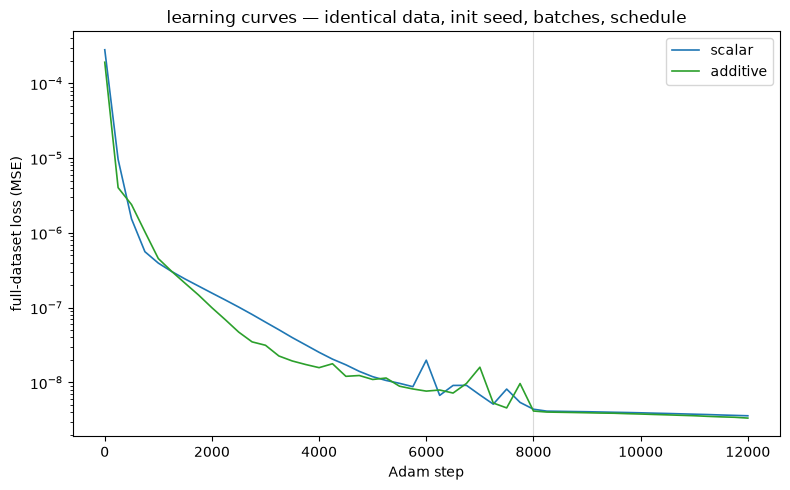

final loss   scalar 3.589e-09   additive 3.342e-09
wall time    scalar 132 s   additive 141 s


In [7]:
fig, a = plt.subplots(figsize=(8, 5))
for (tag, _, _, color), st, lo in [(MODELS[0], steps_s, loss_s),
                                   (MODELS[1], steps_a, loss_a)]:
    a.semilogy(st, lo, color=color, lw=1.2, label=tag)
a.axvline(8000, color='0.85', lw=0.8, zorder=0)
a.set_xlabel('Adam step')
a.set_ylabel('full-dataset loss (MSE)')
a.set_title('learning curves — identical data, init seed, batches, schedule')
a.legend()
plt.tight_layout(); plt.show()

print(f'final loss   scalar {loss_s[-1]:.3e}   additive {loss_a[-1]:.3e}')
print(f'wall time    scalar {wall_s:.0f} s   additive {wall_a:.0f} s')

## 5 — Accuracy: one-step errors and held-out ICs

Free 20 s rollouts from the five held-out interior ICs (Step-5 fractions of the new
box). "Locked" = mean error over the final 5 s below 1.

In [8]:
def one_step_errors(rhs, params):
    f = lambda s, t: rk4_step(lambda s_, t_: rhs(params, s_, t_), s, t, DT_SAVE)
    pred = jax.vmap(f)(s_now, t_now)
    return np.asarray(jnp.linalg.norm(pred - s_next, axis=1))

for tag, rhs, p, _ in MODELS:
    e = one_step_errors(rhs, p)
    print(f'{tag:9s} one-step error   median {np.median(e):.2e}'
          f'   mean {e.mean():.2e}   max {e.max():.2e}')

FRACS = [(0.44, 0.42), (-0.81, -0.72), (0.07, -0.92), (0.93, 0.87),
         (-0.67, 0.0)]
INTERP_ICS = [(round(fx * X0_LIM, 2), round(fv * V0_LIM, 2))
              for fx, fv in FRACS]

LOCK_ERR = 1.0
lock_win = times[:-1] >= T_END - 5.0

def rollout_err(rhs, params, ic):
    s0 = jnp.array(ic)
    tru = np.asarray(simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))
    rol = np.asarray(simulate(lambda s, t: rhs(params, s, t),
                              s0, 0.0, N_SAVE, DT_SAVE, 1))
    err = np.linalg.norm(rol - tru, axis=1)
    locked = err[:-1][lock_win].mean() < LOCK_ERR
    return err.mean(), locked

print()
print('held-out IC rollouts (mean error over 20 s):')
print(f'{"IC":>16s} {"scalar":>12s} {"additive":>12s}   locked?')
for ic in INTERP_ICS:
    row, locks = [], []
    for tag, rhs, p, _ in MODELS:
        e, l = rollout_err(rhs, p, ic)
        row.append(e)
        locks.append(l)
    print(f'{str(ic):>16s} {row[0]:>12.2e} {row[1]:>12.2e}'
          f'   {locks[0]} / {locks[1]}')

scalar    one-step error   median 3.72e-05   mean 5.32e-05   max 1.27e-03
additive  one-step error   median 2.45e-05   mean 3.82e-05   max 2.52e-03

held-out IC rollouts (mean error over 20 s):
              IC       scalar     additive   locked?


    (0.53, 0.59)     7.45e-03     1.05e-02   True / True


  (-0.97, -1.01)     7.56e-02     5.48e-02   True / True


   (0.08, -1.29)     6.96e-03     1.79e-03   True / True


    (1.12, 1.22)     4.19e-02     7.89e-02   True / True


     (-0.8, 0.0)     2.68e-01     2.58e-02   True / True


## 6 — Extrapolation rays, with data coverage

Rays to 1.5× the attractor extent along $x_0$ and 2.5× along $\dot{x}_0$, coverage
strips behind, ▼ = lost phase lock by the end of the rollout.

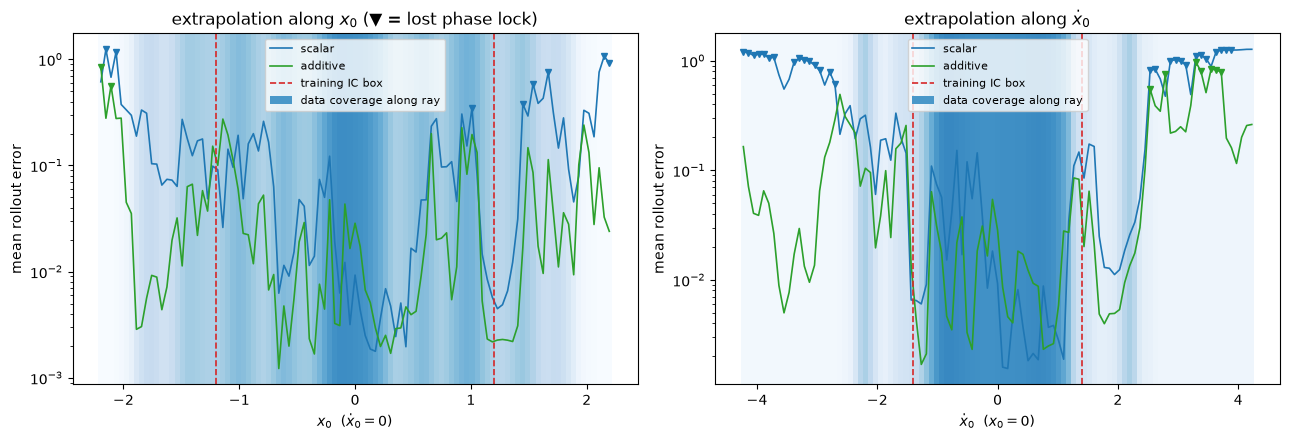

--- ray along x0 ---
  scalar    median err 9.20e-02   lost-lock starts: 8/101
  additive  median err 1.90e-02   lost-lock starts: 2/101
--- ray along v0 ---
  scalar    median err 1.74e-01   lost-lock starts: 28/101
  additive  median err 3.13e-02   lost-lock starts: 7/101


In [9]:
def ray_errors(rhs, params, ics):
    ics = jnp.asarray(ics)
    f = lambda s, t: rhs(params, s, t)
    tru = np.asarray(jax.vmap(
        lambda s0: simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))(ics))
    rol = np.asarray(jax.vmap(
        lambda s0: simulate(f, s0, 0.0, N_SAVE, DT_SAVE, 1))(ics))
    err = np.linalg.norm(rol - tru, axis=2)
    lost = err[:, :-1][:, lock_win].mean(axis=1) > LOCK_ERR
    return err.mean(axis=1), lost

x_ray = np.linspace(-1.5 * EXT_X, 1.5 * EXT_X, 101)
v_ray = np.linspace(-2.5 * EXT_V, 2.5 * EXT_V, 101)
rays = {'x': np.stack([x_ray, np.zeros_like(x_ray)], axis=1),
        'v': np.stack([np.zeros_like(v_ray), v_ray], axis=1)}
res = {tag: {k: ray_errors(rhs, p, ics) for k, ics in rays.items()}
       for tag, rhs, p, _ in MODELS}

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a, keyk, ray, lim, name in [
        (ax[0], 'x', x_ray, X0_LIM, '$x_0$  ($\\dot{x}_0 = 0$)'),
        (ax[1], 'v', v_ray, V0_LIM, '$\\dot{x}_0$  ($x_0 = 0$)')]:
    cov = coverage_at(rays[keyk][:, 0], rays[keyk][:, 1])
    dr = ray[1] - ray[0]
    for xi, ci in zip(ray, cov):
        a.axvspan(xi - dr / 2, xi + dr / 2,
                  color=plt.cm.Blues(0.75 * ci), lw=0, zorder=0)
    for tag, _, _, color in MODELS:
        err, lost = res[tag][keyk]
        a.semilogy(ray, err, color=color, lw=1.2, label=tag)
        a.semilogy(ray[lost], err[lost], 'v', color=color, ms=5)
    a.axvline(-lim, color='tab:red', lw=1.2, ls='--')
    a.axvline(lim, color='tab:red', lw=1.2, ls='--', label='training IC box')
    a.set_xlabel(name); a.set_ylabel('mean rollout error')
    handles, _ = a.get_legend_handles_labels()
    handles.append(Patch(facecolor=plt.cm.Blues(0.6),
                         label='data coverage along ray'))
    a.legend(handles=handles, loc='upper center', fontsize=8)
ax[0].set_title('extrapolation along $x_0$ (▼ = lost phase lock)')
ax[1].set_title('extrapolation along $\\dot{x}_0$')
plt.tight_layout(); plt.show()

for keyk, ray in [('x', x_ray), ('v', v_ray)]:
    print(f'--- ray along {keyk}0 ---')
    for tag, *_ in MODELS:
        err, lost = res[tag][keyk]
        print(f'  {tag:9s} median err {np.median(err):.2e}'
              f'   lost-lock starts: {int(lost.sum())}/{len(ray)}')

## 7 — The long-run test: does the learned model keep the true period?

Run each learned model from `ATTRACTOR_IC` for the same long settle as the truth,
then apply the exact-strobe periodicity table to the **learned** trajectory. The
right panel overlays orbits and strobe points (truth in black, its mirror twin in
grey — a model is also "right" if it lands on the twin).

learned [scalar] strobe periodicity from IC (0.5, 0.0):
   m= 1   max |s(k+m) - s(k)| = 5.19e-01
   m= 2   max |s(k+m) - s(k)| = 1.40e-01
   m= 3   max |s(k+m) - s(k)| = 5.08e-01
   m= 4   max |s(k+m) - s(k)| = 3.01e-02
   m= 6   max |s(k+m) - s(k)| = 1.40e-01
   m= 8   max |s(k+m) - s(k)| = 3.40e-11  <-- period
   m=12   max |s(k+m) - s(k)| = 3.01e-02


learned [additive] strobe periodicity from IC (0.5, 0.0):
   m= 1   max |s(k+m) - s(k)| = 5.11e-01
   m= 2   max |s(k+m) - s(k)| = 1.35e-01
   m= 3   max |s(k+m) - s(k)| = 5.03e-01
   m= 4   max |s(k+m) - s(k)| = 2.17e-02
   m= 6   max |s(k+m) - s(k)| = 1.35e-01
   m= 8   max |s(k+m) - s(k)| = 3.42e-11  <-- period
   m=12   max |s(k+m) - s(k)| = 2.17e-02


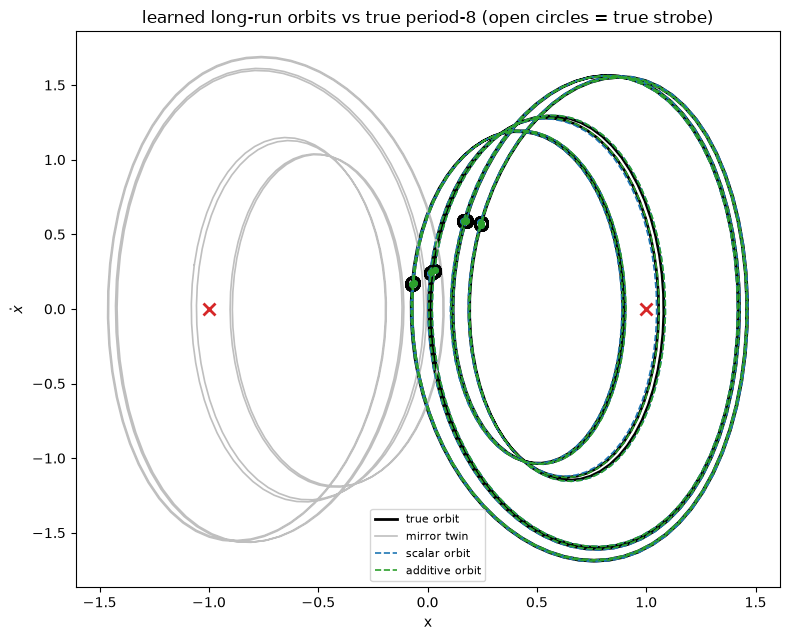

In [10]:
_, mir_sp_all = strobe_run(true_rhs, (-ATTRACTOR_IC[0], -ATTRACTOR_IC[1]),
                           N_SETTLE + N_MEAS, 4)
mir_full, _ = strobe_run(true_rhs, (-ATTRACTOR_IC[0], -ATTRACTOR_IC[1]),
                         N_SETTLE + PERIOD_N, 4)
mir_orbit = mir_full[N_SETTLE * SPP:]
mir_sp = mir_sp_all[N_SETTLE:]

fig, a = plt.subplots(figsize=(8, 6.5))
a.plot(orbit[:, 0], orbit[:, 1], 'k', lw=2.0, label='true orbit')
a.plot(mir_orbit[:, 0], mir_orbit[:, 1], color='0.75', lw=1.2,
       label='mirror twin')
a.plot(sp_true[:, 0], sp_true[:, 1], 'o', color='k', ms=9, mfc='none',
       mew=1.8)
for tag, rhs, p, color in MODELS:
    lfull, lsp_all = strobe_run(lambda s, t: rhs(p, s, t), ATTRACTOR_IC,
                                N_SETTLE + N_MEAS, 1)
    lorbit = lfull[N_SETTLE * SPP:(N_SETTLE + PERIOD_N) * SPP + 1]
    lsp = lsp_all[N_SETTLE:]
    print(f'learned [{tag}] strobe periodicity from IC {ATTRACTOR_IC}:')
    period_table(lsp)
    a.plot(lorbit[:, 0], lorbit[:, 1], '--', color=color, lw=1.2,
           label=f'{tag} orbit')
    a.plot(lsp[:, 0], lsp[:, 1], '.', color=color, ms=7)
a.plot([-1, 1], [0, 0], 'x', color='tab:red', ms=8, mew=2)
a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')
a.set_title(f'learned long-run orbits vs true period-{PERIOD_N}'
            ' (open circles = true strobe)')
a.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8 — The learned forces, term by term

Gauge-fixed as in Steps 4–5: $g$ shifted to zero mean over the drive cycle, $d$
shifted so $d(0) = 0$, both shifts absorbed into $f$.

gauge constants:  mean(g) = +0.0031   d(0) = -0.0512   (moved into f)


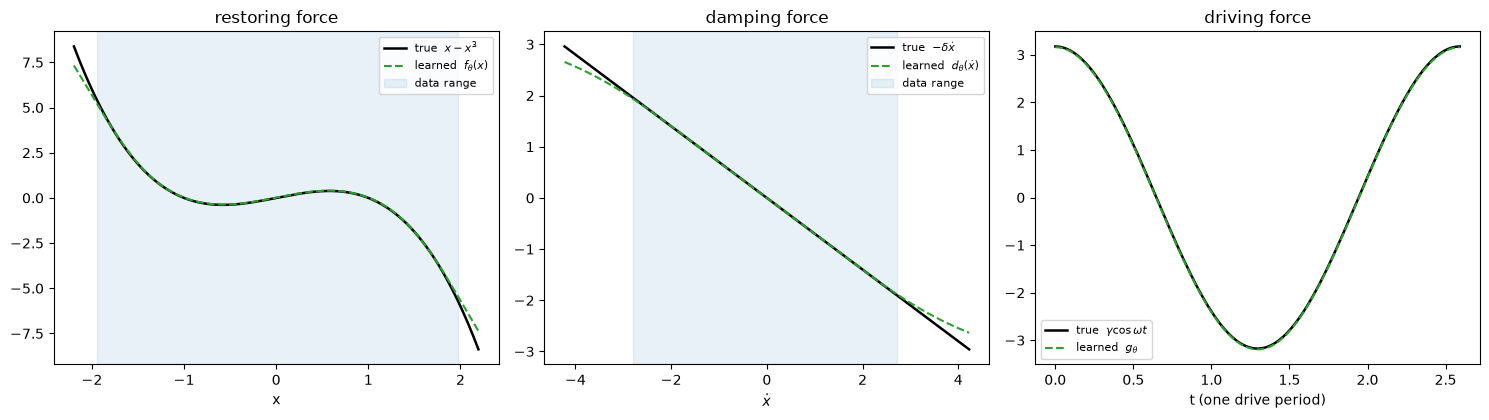

max |f error|   in data range 2.63e-01   at edges of plot: 1.05e+00
max |d error|   in data range 2.19e-02
max |g error|   1.93e-02


In [11]:
term_f = jax.vmap(lambda x: additive_terms(params_a,
                  jnp.array([x, 0.0]), 0.0)[0])
term_d = jax.vmap(lambda v: additive_terms(params_a,
                  jnp.array([0.0, v]), 0.0)[1])

t_cycle = np.linspace(0.0, T_DRIVE, 200)
term_g = jax.vmap(lambda t: additive_terms(params_a,
                  jnp.array([0.0, 0.0]), t)[2])

g_vals = np.asarray(term_g(jnp.asarray(t_cycle)))
c_g = g_vals.mean()
c_d = float(term_d(jnp.array([0.0]))[0])
print(f'gauge constants:  mean(g) = {c_g:+.4f}   d(0) = {c_d:+.4f}'
      f'   (moved into f)')

x_plot = np.linspace(-1.5 * EXT_X, 1.5 * EXT_X, 400)
v_plot = np.linspace(-2.5 * EXT_V, 2.5 * EXT_V, 400)
f_vals = np.asarray(term_f(jnp.asarray(x_plot))) + c_g + c_d
d_vals = np.asarray(term_d(jnp.asarray(v_plot))) - c_d
g_tilde = g_vals - c_g

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
a = ax[0]
a.plot(x_plot, x_plot - x_plot**3, 'k', lw=1.8, label='true  $x - x^3$')
a.plot(x_plot, f_vals, '--', color='tab:green', lw=1.5,
       label=r'learned  $f_\theta(x)$')
a.axvspan(pts[:, 0].min(), pts[:, 0].max(), color='tab:blue', alpha=0.10,
          label='data range')
a.set_xlabel('x'); a.set_title('restoring force')
a.legend(fontsize=8)

a = ax[1]
a.plot(v_plot, -DELTA * v_plot, 'k', lw=1.8,
       label=r'true  $-\delta\dot{x}$')
a.plot(v_plot, d_vals, '--', color='tab:green', lw=1.5,
       label=r'learned  $d_\theta(\dot{x})$')
a.axvspan(pts[:, 1].min(), pts[:, 1].max(), color='tab:blue', alpha=0.10,
          label='data range')
a.set_xlabel(r'$\dot{x}$'); a.set_title('damping force')
a.legend(fontsize=8)

a = ax[2]
a.plot(t_cycle, GAMMA * np.cos(OMEGA * t_cycle), 'k', lw=1.8,
       label=r'true  $\gamma\cos\omega t$')
a.plot(t_cycle, g_tilde, '--', color='tab:green', lw=1.5,
       label=r'learned  $g_\theta$')
a.set_xlabel('t (one drive period)'); a.set_title('driving force')
a.legend(fontsize=8)
plt.tight_layout(); plt.show()

in_x = (x_plot > pts[:, 0].min()) & (x_plot < pts[:, 0].max())
in_v = (v_plot > pts[:, 1].min()) & (v_plot < pts[:, 1].max())
f_err = np.abs(f_vals - (x_plot - x_plot**3))
print(f'max |f error|   in data range {f_err[in_x].max():.2e}'
      f'   at edges of plot: {f_err[[0, -1]].max():.2e}')
print(f'max |d error|   in data range {np.abs(d_vals + DELTA * v_plot)[in_v].max():.2e}')
print(f'max |g error|   {np.abs(g_tilde - GAMMA * np.cos(OMEGA * t_cycle)).max():.2e}')

## What this rung settles

Read off the results above:

1. **Rollout accuracy** transfers from Step 5 or doesn't — same box-scaled data
   recipe, same budgets, weaker contraction to forgive mistakes.
2. **The learned strobe table is the sharp test**: period-8 means the model's own
   strobe residual should dip at $m = 8$ (and only partially at $m = 4$ — the pair
   splitting is real structure, size $\approx 0.02$). A model that is right to
   $\mathcal{O}(10^{-2})$ in the vector field can still land on the wrong rung of the
   cascade, because the doubling gap *is* $\mathcal{O}(10^{-2})$.
3. **The forces panel** says whether the additive decomposition stays exact when the
   attractor is more delicate than the force laws themselves.

Companion notebook: `duffing_node_p3.ipynb` — the period-3 regime, where a chaotic
attractor coexists with the periodic one.


---

# Part C — Step 6b: period-3 with a chaotic roommate

δ=0.7, γ=3.325, ω=2.3. Coexisting attractors; the chaos-dust panel (additive collapses the chaotic set). Each part is self-contained (re-defines its own globals).

---


# Duffing Neural ODE — Step 6b: the period-3 regime (with a chaotic roommate)

$\delta = 0.7$, $\gamma = 3.325$, $\omega = 2.3$. Pre-characterization on our
integrator turned up more than the atlas label:

- from IC $(1.5, 1.0)$: a **genuine period-3 cross-well orbit** — strobe returns
  after exactly 3 drive periods (residual $\sim 2\times10^{-9}$),
  $\lambda \approx -0.05\,/\mathrm{s}$; odd symmetry supplies a mirror twin;
- from IC $(0.5, 0.0)$: **still aperiodic after 1100 drive periods**, with
  $\lambda \approx +0.05\,/\mathrm{s}$ — a **chaotic attractor coexists** with the
  period-3 pair. The atlas's single-IC label caught the P3; the phase plane is
  actually shared between the two;
- extents are nearly identical for both sets: $|x| \lesssim 1.42$,
  $|\dot{x}| \lesssim 1.71$.

So the training grid samples **both attractors** — the data teaches the vector field,
not one orbit, and the interesting long-run question splits in two: started on the
period-3 orbit, does a learned model hold period 3? Started in the chaotic sea, does
it stay aperiodic (positive Lyapunov) rather than collapsing onto the easy periodic
orbit?

Same two models and training process as Step 5 (scalar black box vs additive
$f_\theta(x) + d_\theta(\dot{x}) + g_\theta(\cos\omega t, \sin\omega t)$, both with
$\dot{x}_1 = x_2$ hardwired).

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

jax.config.update('jax_enable_x64', True)

DELTA, GAMMA, OMEGA = 0.7, 3.325, 2.3
T_DRIVE = 2 * np.pi / OMEGA
PERIOD_N = 3
ATTRACTOR_IC = (1.5, 1.0)
SECOND_IC = (0.5, 0.0)
TAG = 'p3'

def true_rhs(s, t):
    x, v = s
    return jnp.array([v, -DELTA * v + x - x**3 + GAMMA * jnp.cos(OMEGA * t)])

def rk4_step(f, s, t, dt):
    k1 = f(s, t)
    k2 = f(s + 0.5 * dt * k1, t + 0.5 * dt)
    k3 = f(s + 0.5 * dt * k2, t + 0.5 * dt)
    k4 = f(s + dt * k3, t + dt)
    return s + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def simulate(f, s0, t0, n_save, dt_save, substeps):
    dt = dt_save / substeps
    def sub(c, _):
        s, t = c
        return (rk4_step(f, s, t, dt), t + dt), None
    def save_step(carry, _):
        carry, _ = jax.lax.scan(sub, carry, None, length=substeps)
        return carry, carry[0]
    _, traj = jax.lax.scan(save_step, (s0, t0), None, length=n_save)
    return jnp.concatenate([s0[None], traj])

DT_INT, DT_SAVE = 0.005, 0.01
SUBS = int(round(DT_SAVE / DT_INT))

# exact-strobe machinery: save step locked to T_DRIVE/SPP so strobe samples land
# exactly on drive-period multiples (a 0.01-grid strobe smears points by ~1e-2,
# which is the same size as the structure we need to resolve)
SPP = 64
DT_STROBE = T_DRIVE / SPP

def strobe_run(f, s0, n_per, substeps):
    traj = np.asarray(simulate(f, jnp.array(s0), 0.0, n_per * SPP,
                               DT_STROBE, substeps))
    return traj, traj[::SPP]

def period_table(sp, ms=(1, 2, 3, 4, 6, 8, 12)):
    for m in ms:
        d = np.linalg.norm(sp[m:] - sp[:-m], axis=1).max()
        marker = '  <-- period' if d < 1e-6 else ''
        print(f'   m={m:2d}   max |s(k+m) - s(k)| = {d:.2e}{marker}')

## 0 — Regime tour

Dense trajectory, steady-state phase portrait (one full $n T$ orbit segment), and the
exact strobe section with the periodicity table: the residual
$\max_k \|s(k{+}m) - s(k)\|$ over late strobes drops to integrator precision exactly at
the true period multiple.

Two starts here: `ATTRACTOR_IC` lands on the period-3 orbit; `SECOND_IC` lands on the
coexisting chaotic set, shown as strobe dust.

attractor extent:  |x| <= 1.761   |xdot| <= 2.437
strobe periodicity from IC (1.5, 1.0) (last 80 of 480 periods):
   m= 1   max |s(k+m) - s(k)| = 2.20e+00
   m= 2   max |s(k+m) - s(k)| = 2.20e+00
   m= 3   max |s(k+m) - s(k)| = 1.42e-10  <-- period
   m= 4   max |s(k+m) - s(k)| = 2.20e+00
   m= 6   max |s(k+m) - s(k)| = 2.83e-10  <-- period
   m= 8   max |s(k+m) - s(k)| = 2.20e+00
   m=12   max |s(k+m) - s(k)| = 5.66e-10  <-- period
strobe periodicity from IC (0.5, 0.0):
   m= 1   max |s(k+m) - s(k)| = 6.69e-01
   m= 2   max |s(k+m) - s(k)| = 2.24e-01
   m= 3   max |s(k+m) - s(k)| = 6.52e-01
   m= 4   max |s(k+m) - s(k)| = 1.13e-01
   m= 6   max |s(k+m) - s(k)| = 2.12e-01
   m= 8   max |s(k+m) - s(k)| = 8.81e-02
   m=12   max |s(k+m) - s(k)| = 9.85e-02


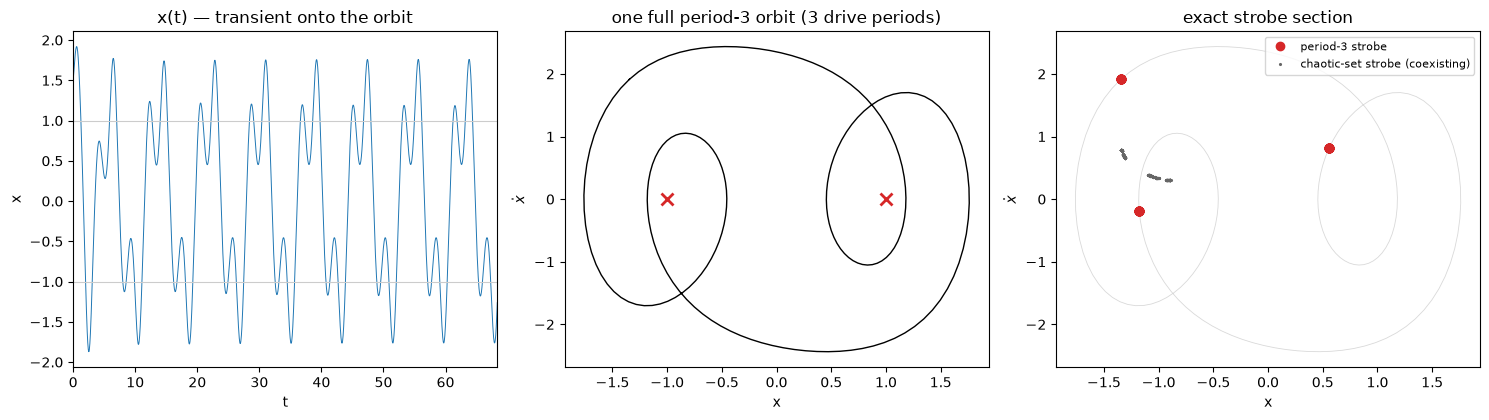

In [2]:
N_SETTLE, N_MEAS = 400, 80
tour_full, tour_sp = strobe_run(true_rhs, ATTRACTOR_IC,
                                N_SETTLE + N_MEAS, 4)
steady_tr = tour_full[N_SETTLE * SPP:]
sp_true = tour_sp[N_SETTLE:]
orbit = tour_full[N_SETTLE * SPP:(N_SETTLE + PERIOD_N) * SPP + 1]

EXT_X = float(np.abs(steady_tr[:, 0]).max())
EXT_V = float(np.abs(steady_tr[:, 1]).max())
print(f'attractor extent:  |x| <= {EXT_X:.3f}   |xdot| <= {EXT_V:.3f}')
print(f'strobe periodicity from IC {ATTRACTOR_IC} '
      f'(last {N_MEAS} of {N_SETTLE + N_MEAS} periods):')
period_table(sp_true)

if SECOND_IC is not None:
    chaos_full, chaos_sp_all = strobe_run(true_rhs, SECOND_IC,
                                          N_SETTLE + N_MEAS * 4, 4)
    chaos_sp = chaos_sp_all[N_SETTLE:]
    print(f'strobe periodicity from IC {SECOND_IC}:')
    period_table(chaos_sp)

t_dense = np.arange(len(tour_full)) * DT_STROBE

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
a = ax[0]
a.plot(t_dense, tour_full[:, 0], lw=0.7)
a.axhline(1, color='0.8', lw=0.8)
a.axhline(-1, color='0.8', lw=0.8)
a.set_xlim(0, 25 * T_DRIVE)
a.set_xlabel('t'); a.set_ylabel('x')
a.set_title('x(t) — transient onto the orbit')

a = ax[1]
a.plot(orbit[:, 0], orbit[:, 1], 'k', lw=1.0)
a.plot([-1, 1], [0, 0], 'x', color='tab:red', ms=8, mew=2)
a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')
a.set_title(f'one full period-{PERIOD_N} orbit ({PERIOD_N} drive periods)')

a = ax[2]
a.plot(orbit[:, 0], orbit[:, 1], color='0.85', lw=0.6, zorder=0)
a.plot(sp_true[:, 0], sp_true[:, 1], 'o', color='tab:red', ms=6,
       label=f'period-{PERIOD_N} strobe')
if SECOND_IC is not None:
    a.plot(chaos_sp[:, 0], chaos_sp[:, 1], '.', color='0.4', ms=2.5,
           label='chaotic-set strobe (coexisting)')
    a.legend(fontsize=8)
a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')
a.set_title('exact strobe section')
plt.tight_layout(); plt.show()

## 1 — Training data, auto-scaled to the attractor

Same recipe as Step 5: 9×7 IC grid at 80% of the measured extent, 20 s per
trajectory. Contraction is weak here, so these trajectories are mostly transient —
which is exactly what one-step vector-field training wants: broad phase-space
coverage, not one settled orbit.

In [3]:
T_END = 20.0
N_SAVE = int(round(T_END / DT_SAVE))
times = np.arange(N_SAVE + 1) * DT_SAVE

X0_LIM = round(0.8 * EXT_X, 1)
V0_LIM = round(0.8 * EXT_V, 1)
print(f'IC box: x0 in [-{X0_LIM}, {X0_LIM}]   xdot0 in [-{V0_LIM}, {V0_LIM}]')

ic_grid = np.stack(np.meshgrid(np.linspace(-X0_LIM, X0_LIM, 9),
                               np.linspace(-V0_LIM, V0_LIM, 7),
                               indexing='ij'), axis=-1).reshape(-1, 2)

sim_batch = jax.vmap(lambda s0: simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))
trajs = np.asarray(sim_batch(jnp.asarray(ic_grid)))
print('training trajectories:', trajs.shape)

IC box: x0 in [-1.4, 1.4]   xdot0 in [-1.9, 1.9]
training trajectories: (63, 2001, 2)


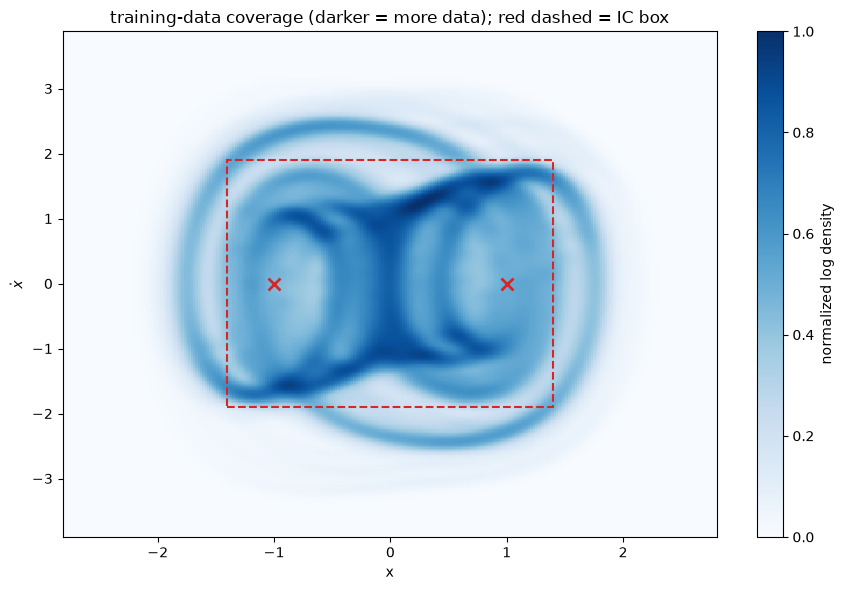

In [4]:
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Rectangle, Patch

pts = trajs[:, :-1, :].reshape(-1, 2)
BIN, SIG = 0.02, 0.08
XB = np.arange(-1.6 * EXT_X, 1.6 * EXT_X + 1e-9, BIN)
VB = np.arange(-1.6 * EXT_V, 1.6 * EXT_V + 1e-9, BIN)
H, _, _ = np.histogram2d(pts[:, 0], pts[:, 1], bins=[XB, VB])
D_log = np.log10(1.0 + gaussian_filter(H, SIG / BIN))
D_norm = D_log / D_log.max()
xc = 0.5 * (XB[:-1] + XB[1:])
vc = 0.5 * (VB[:-1] + VB[1:])

def coverage_at(x, v):
    i = np.clip(np.searchsorted(xc, x), 0, len(xc) - 1)
    j = np.clip(np.searchsorted(vc, v), 0, len(vc) - 1)
    return D_norm[i, j]

fig, a = plt.subplots(figsize=(9, 6))
pc = a.pcolormesh(XB, VB, D_norm.T, cmap='Blues', vmin=0, vmax=1,
                  rasterized=True)
a.add_patch(Rectangle((-X0_LIM, -V0_LIM), 2 * X0_LIM, 2 * V0_LIM,
                      fill=False, edgecolor='tab:red', ls='--', lw=1.5))
a.plot([-1, 1], [0, 0], 'x', color='tab:red', ms=8, mew=2)
a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')
a.set_title('training-data coverage (darker = more data);'
            ' red dashed = IC box')
fig.colorbar(pc, ax=a, label='normalized log density')
plt.tight_layout(); plt.show()

## 2 — The two models

In [5]:
def init_mlp(key, layers):
    params = []
    for n_in, n_out in zip(layers[:-1], layers[1:]):
        key, k = jax.random.split(key)
        W = jax.random.normal(k, (n_in, n_out)) * jnp.sqrt(1.0 / n_in)
        params.append((W, jnp.zeros(n_out)))
    return params

def mlp(params, u):
    h = u
    for W, b in params[:-1]:
        h = jnp.tanh(h @ W + b)
    W, b = params[-1]
    return h @ W + b

def make_input(s, t):
    return jnp.array([s[0], s[1], jnp.cos(OMEGA * t), jnp.sin(OMEGA * t)])

LAYERS_SCALAR = [4, 64, 64, 1]
def init_scalar(key):
    return init_mlp(key, LAYERS_SCALAR)
def rhs_scalar(params, s, t):
    a = mlp(params, make_input(s, t))[0]
    return jnp.array([s[1], a])

F_LAYERS = [1, 32, 32, 1]
D_LAYERS = [1, 32, 32, 1]
G_LAYERS = [2, 32, 32, 1]
N_F, N_D = len(F_LAYERS) - 1, len(D_LAYERS) - 1

def init_additive(key):
    kf, kd, kg = jax.random.split(key, 3)
    return (init_mlp(kf, F_LAYERS) + init_mlp(kd, D_LAYERS)
            + init_mlp(kg, G_LAYERS))

def additive_terms(params, s, t):
    pf = params[:N_F]
    pd = params[N_F:N_F + N_D]
    pg = params[N_F + N_D:]
    f = mlp(pf, jnp.array([s[0]]))[0]
    d = mlp(pd, jnp.array([s[1]]))[0]
    g = mlp(pg, jnp.array([jnp.cos(OMEGA * t), jnp.sin(OMEGA * t)]))[0]
    return f, d, g

def rhs_additive(params, s, t):
    f, d, g = additive_terms(params, s, t)
    return jnp.array([s[1], f + d + g])

for name, init in [('scalar', init_scalar), ('additive', init_additive)]:
    n = sum(W.size + b.size for W, b in init(jax.random.PRNGKey(0)))
    print(f'{name:9s} parameters: {n}')

scalar    parameters: 4545


additive  parameters: 3491


## 3 — Training

Identical harness to Step 5; caches `params_<tag>_<model>.npz` (delete to
retrain).

In [6]:
import os

s_now = jnp.asarray(trajs[:, :-1, :].reshape(-1, 2))
s_next = jnp.asarray(trajs[:, 1:, :].reshape(-1, 2))
t_now = jnp.asarray(np.tile(times[:-1], len(ic_grid)))
N_PAIRS = s_now.shape[0]
print('training pairs:', N_PAIRS)

def adam_update(params, grads, m, v, step, lr, b1=0.9, b2=0.999, eps=1e-8):
    m = jax.tree.map(lambda m_, g: b1 * m_ + (1 - b1) * g, m, grads)
    v = jax.tree.map(lambda v_, g: b2 * v_ + (1 - b2) * g * g, v, grads)
    mhat = jax.tree.map(lambda m_: m_ / (1 - b1 ** step), m)
    vhat = jax.tree.map(lambda v_: v_ / (1 - b2 ** step), v)
    new = jax.tree.map(lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
                       params, mhat, vhat)
    return new, m, v

BATCH = 16384
N_STEPS = 12000
EVAL_EVERY = 250

def train(rhs, init_fn, model_tag):
    def one_step(params, s, t):
        return rk4_step(lambda s_, t_: rhs(params, s_, t_), s, t, DT_SAVE)

    def loss_on(params, sb, snb, tb):
        pred = jax.vmap(lambda s, t: one_step(params, s, t))(sb, tb)
        return jnp.mean((pred - snb) ** 2)

    full_loss = jax.jit(lambda p: loss_on(p, s_now, s_next, t_now))

    cache = f'params_{TAG}_{model_tag}.npz'
    if os.path.exists(cache):
        z = np.load(cache)
        n_layers = sum(1 for k in z.files if k.startswith('W'))
        params = [(jnp.asarray(z[f'W{i}']), jnp.asarray(z[f'b{i}']))
                  for i in range(n_layers)]
        print(f'[{model_tag}] loaded cached params from {cache}   '
              f'full loss {float(full_loss(params)):.3e}   '
              f'(delete the file to retrain)')
        return (params, z['hist_steps'], z['hist_loss'], full_loss,
                float(z['wall']))

    @jax.jit
    def train_step(params, m, v, step, lr, key):
        idx = jax.random.randint(key, (BATCH,), 0, N_PAIRS)
        loss, grads = jax.value_and_grad(loss_on)(params, s_now[idx],
                                                  s_next[idx], t_now[idx])
        params, m, v = adam_update(params, grads, m, v, step, lr)
        return params, m, v, loss

    params = init_fn(jax.random.PRNGKey(0))
    m = jax.tree.map(jnp.zeros_like, params)
    v = jax.tree.map(jnp.zeros_like, params)
    base_key = jax.random.PRNGKey(1)

    hist_steps, hist_loss = [], []
    t0 = time.time()
    for i in range(1, N_STEPS + 1):
        lr = 1e-3 if i <= 8000 else 1e-4
        params, m, v, _ = train_step(params, m, v, float(i), lr,
                                     jax.random.fold_in(base_key, i))
        if i == 1 or i % EVAL_EVERY == 0:
            fl = float(full_loss(params))
            hist_steps.append(i)
            hist_loss.append(fl)
            if i == 1 or i % 2000 == 0:
                print(f'[{model_tag}] step {i:6d}   lr {lr:.0e}'
                      f'   full loss {fl:.3e}')
    wall = time.time() - t0
    print(f'[{model_tag}] final full loss {hist_loss[-1]:.3e}'
          f'   wall time {wall:.0f} s')
    np.savez(cache, hist_steps=np.array(hist_steps),
             hist_loss=np.array(hist_loss), wall=wall,
             **{f'W{i}': np.asarray(Wt) for i, (Wt, _) in enumerate(params)},
             **{f'b{i}': np.asarray(bt) for i, (_, bt) in enumerate(params)})
    return params, np.array(hist_steps), np.array(hist_loss), full_loss, wall

params_s, steps_s, loss_s, _, wall_s = train(rhs_scalar, init_scalar, 'scalar')
params_a, steps_a, loss_a, _, wall_a = train(rhs_additive, init_additive,
                                             'additive')

MODELS = [('scalar', rhs_scalar, params_s, 'tab:blue'),
          ('additive', rhs_additive, params_a, 'tab:green')]

training pairs: 126000


[scalar] step      1   lr 1e-03   full loss 3.419e-04


[scalar] step   2000   lr 1e-03   full loss 2.017e-07


[scalar] step   4000   lr 1e-03   full loss 2.363e-08


[scalar] step   6000   lr 1e-03   full loss 1.077e-08


...

[additive] step   4000   lr 1e-03   full loss 2.760e-08


[additive] step   6000   lr 1e-03   full loss 1.134e-08


[additive] step   8000   lr 1e-03   full loss 5.369e-09


[additive] step  10000   lr 1e-04   full loss 4.270e-09


[additive] step  12000   lr 1e-04   full loss 3.693e-09
[additive] final full loss 3.693e-09   wall time 142 s


## 4 — Learning curves

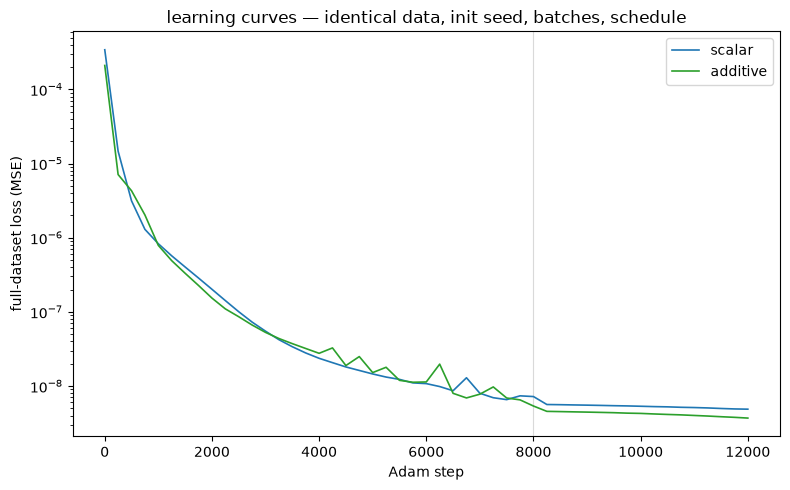

final loss   scalar 4.869e-09   additive 3.693e-09
wall time    scalar 131 s   additive 142 s


In [7]:
fig, a = plt.subplots(figsize=(8, 5))
for (tag, _, _, color), st, lo in [(MODELS[0], steps_s, loss_s),
                                   (MODELS[1], steps_a, loss_a)]:
    a.semilogy(st, lo, color=color, lw=1.2, label=tag)
a.axvline(8000, color='0.85', lw=0.8, zorder=0)
a.set_xlabel('Adam step')
a.set_ylabel('full-dataset loss (MSE)')
a.set_title('learning curves — identical data, init seed, batches, schedule')
a.legend()
plt.tight_layout(); plt.show()

print(f'final loss   scalar {loss_s[-1]:.3e}   additive {loss_a[-1]:.3e}')
print(f'wall time    scalar {wall_s:.0f} s   additive {wall_a:.0f} s')

## 5 — Accuracy: one-step errors and held-out ICs

Free 20 s rollouts from the five held-out interior ICs (Step-5 fractions of the new
box). "Locked" = mean error over the final 5 s below 1.
With a chaotic attractor in the mix, ICs whose true trajectory is chaotic
($\lambda \approx +0.05\,/\mathrm{s}$) drift from any model at late times; 20 s
$\approx$ 1 e-fold, so the numbers stay meaningful but chaotic-basin rows read softer
for both models.

In [8]:
def one_step_errors(rhs, params):
    f = lambda s, t: rk4_step(lambda s_, t_: rhs(params, s_, t_), s, t, DT_SAVE)
    pred = jax.vmap(f)(s_now, t_now)
    return np.asarray(jnp.linalg.norm(pred - s_next, axis=1))

for tag, rhs, p, _ in MODELS:
    e = one_step_errors(rhs, p)
    print(f'{tag:9s} one-step error   median {np.median(e):.2e}'
          f'   mean {e.mean():.2e}   max {e.max():.2e}')

FRACS = [(0.44, 0.42), (-0.81, -0.72), (0.07, -0.92), (0.93, 0.87),
         (-0.67, 0.0)]
INTERP_ICS = [(round(fx * X0_LIM, 2), round(fv * V0_LIM, 2))
              for fx, fv in FRACS]

LOCK_ERR = 1.0
lock_win = times[:-1] >= T_END - 5.0

def rollout_err(rhs, params, ic):
    s0 = jnp.array(ic)
    tru = np.asarray(simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))
    rol = np.asarray(simulate(lambda s, t: rhs(params, s, t),
                              s0, 0.0, N_SAVE, DT_SAVE, 1))
    err = np.linalg.norm(rol - tru, axis=1)
    locked = err[:-1][lock_win].mean() < LOCK_ERR
    return err.mean(), locked

print()
print('held-out IC rollouts (mean error over 20 s):')
print(f'{"IC":>16s} {"scalar":>12s} {"additive":>12s}   locked?')
for ic in INTERP_ICS:
    row, locks = [], []
    for tag, rhs, p, _ in MODELS:
        e, l = rollout_err(rhs, p, ic)
        row.append(e)
        locks.append(l)
    print(f'{str(ic):>16s} {row[0]:>12.2e} {row[1]:>12.2e}'
          f'   {locks[0]} / {locks[1]}')

scalar    one-step error   median 4.04e-05   mean 5.93e-05   max 2.36e-03
additive  one-step error   median 2.45e-05   mean 3.79e-05   max 3.55e-03

held-out IC rollouts (mean error over 20 s):
              IC       scalar     additive   locked?


     (0.62, 0.8)     3.11e-03     1.79e-03   True / True


  (-1.13, -1.37)     9.83e-02     9.40e-03   True / True


    (0.1, -1.75)     1.74e-01     1.70e-01   True / True


     (1.3, 1.65)     1.86e-02     1.27e-02   True / True


    (-0.94, 0.0)     1.24e-02     2.00e-03   True / True


## 6 — Extrapolation rays, with data coverage

Rays to 1.5× the attractor extent along $x_0$ and 2.5× along $\dot{x}_0$, coverage
strips behind, ▼ = lost phase lock by the end of the rollout.

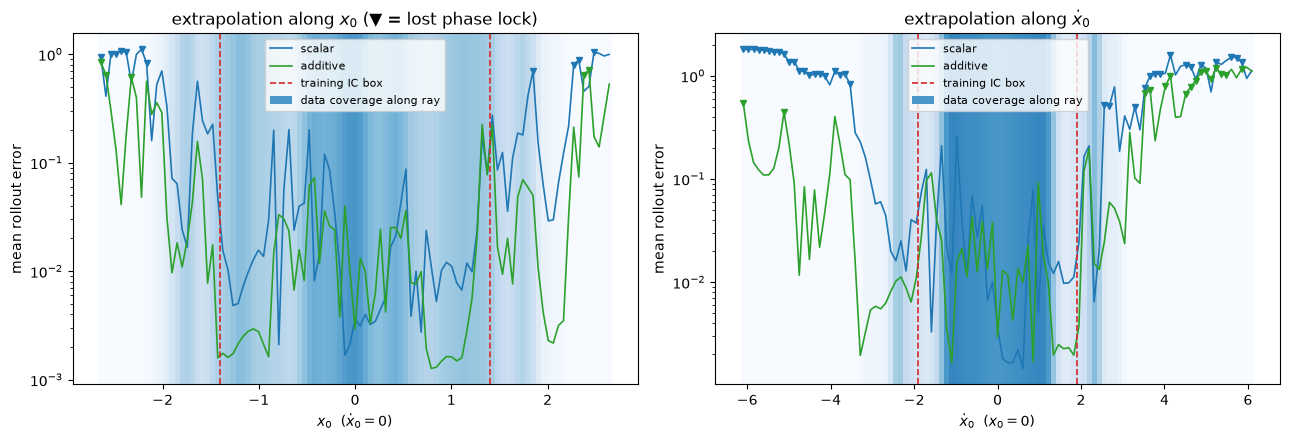

--- ray along x0 ---
  scalar    median err 5.66e-02   lost-lock starts: 11/101
  additive  median err 1.82e-02   lost-lock starts: 5/101
--- ray along v0 ---
  scalar    median err 2.99e-01   lost-lock starts: 36/101
  additive  median err 4.66e-02   lost-lock starts: 16/101


In [9]:
def ray_errors(rhs, params, ics):
    ics = jnp.asarray(ics)
    f = lambda s, t: rhs(params, s, t)
    tru = np.asarray(jax.vmap(
        lambda s0: simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))(ics))
    rol = np.asarray(jax.vmap(
        lambda s0: simulate(f, s0, 0.0, N_SAVE, DT_SAVE, 1))(ics))
    err = np.linalg.norm(rol - tru, axis=2)
    lost = err[:, :-1][:, lock_win].mean(axis=1) > LOCK_ERR
    return err.mean(axis=1), lost

x_ray = np.linspace(-1.5 * EXT_X, 1.5 * EXT_X, 101)
v_ray = np.linspace(-2.5 * EXT_V, 2.5 * EXT_V, 101)
rays = {'x': np.stack([x_ray, np.zeros_like(x_ray)], axis=1),
        'v': np.stack([np.zeros_like(v_ray), v_ray], axis=1)}
res = {tag: {k: ray_errors(rhs, p, ics) for k, ics in rays.items()}
       for tag, rhs, p, _ in MODELS}

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a, keyk, ray, lim, name in [
        (ax[0], 'x', x_ray, X0_LIM, '$x_0$  ($\\dot{x}_0 = 0$)'),
        (ax[1], 'v', v_ray, V0_LIM, '$\\dot{x}_0$  ($x_0 = 0$)')]:
    cov = coverage_at(rays[keyk][:, 0], rays[keyk][:, 1])
    dr = ray[1] - ray[0]
    for xi, ci in zip(ray, cov):
        a.axvspan(xi - dr / 2, xi + dr / 2,
                  color=plt.cm.Blues(0.75 * ci), lw=0, zorder=0)
    for tag, _, _, color in MODELS:
        err, lost = res[tag][keyk]
        a.semilogy(ray, err, color=color, lw=1.2, label=tag)
        a.semilogy(ray[lost], err[lost], 'v', color=color, ms=5)
    a.axvline(-lim, color='tab:red', lw=1.2, ls='--')
    a.axvline(lim, color='tab:red', lw=1.2, ls='--', label='training IC box')
    a.set_xlabel(name); a.set_ylabel('mean rollout error')
    handles, _ = a.get_legend_handles_labels()
    handles.append(Patch(facecolor=plt.cm.Blues(0.6),
                         label='data coverage along ray'))
    a.legend(handles=handles, loc='upper center', fontsize=8)
ax[0].set_title('extrapolation along $x_0$ (▼ = lost phase lock)')
ax[1].set_title('extrapolation along $\\dot{x}_0$')
plt.tight_layout(); plt.show()

for keyk, ray in [('x', x_ray), ('v', v_ray)]:
    print(f'--- ray along {keyk}0 ---')
    for tag, *_ in MODELS:
        err, lost = res[tag][keyk]
        print(f'  {tag:9s} median err {np.median(err):.2e}'
              f'   lost-lock starts: {int(lost.sum())}/{len(ray)}')

## 7 — The long-run test: does the learned model keep the true period?

Run each learned model from `ATTRACTOR_IC` for the same long settle as the truth,
then apply the exact-strobe periodicity table to the **learned** trajectory. The
right panel overlays orbits and strobe points (truth in black, its mirror twin in
grey — a model is also "right" if it lands on the twin).

Then the chaotic side: from `SECOND_IC` the truth stays aperiodic forever. The
learned models can't track it pointwise, but a faithful model's strobe cloud should
remain dust over the same region — collapsing to a few points means the chaos was
lost.

learned [scalar] strobe periodicity from IC (1.5, 1.0):
   m= 1   max |s(k+m) - s(k)| = 2.21e+00
   m= 2   max |s(k+m) - s(k)| = 2.21e+00
   m= 3   max |s(k+m) - s(k)| = 2.88e-11  <-- period
   m= 4   max |s(k+m) - s(k)| = 2.21e+00
   m= 6   max |s(k+m) - s(k)| = 5.76e-11  <-- period
   m= 8   max |s(k+m) - s(k)| = 2.21e+00
   m=12   max |s(k+m) - s(k)| = 1.15e-10  <-- period


learned [additive] strobe periodicity from IC (1.5, 1.0):
   m= 1   max |s(k+m) - s(k)| = 2.20e+00
   m= 2   max |s(k+m) - s(k)| = 2.20e+00
   m= 3   max |s(k+m) - s(k)| = 2.93e-11  <-- period
   m= 4   max |s(k+m) - s(k)| = 2.20e+00
   m= 6   max |s(k+m) - s(k)| = 5.85e-11  <-- period
   m= 8   max |s(k+m) - s(k)| = 2.20e+00
   m=12   max |s(k+m) - s(k)| = 1.17e-10  <-- period


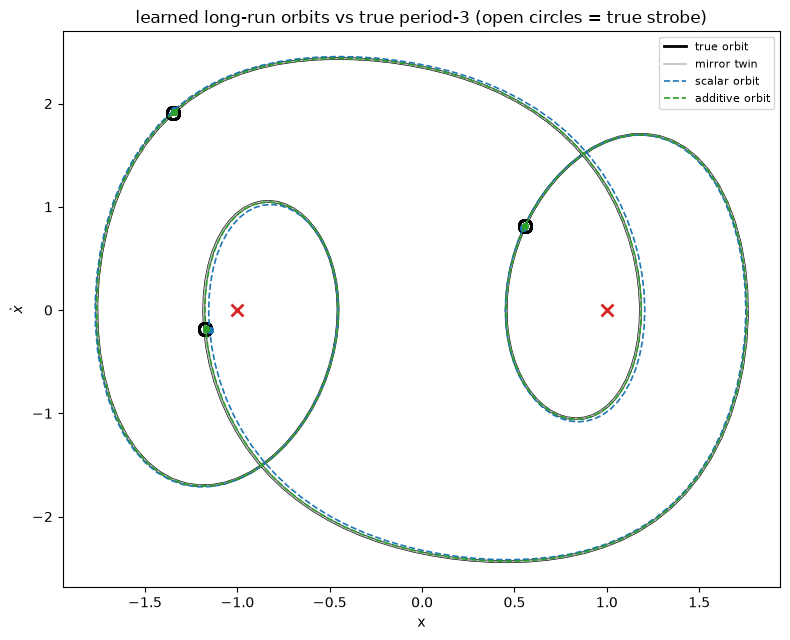

In [10]:
_, mir_sp_all = strobe_run(true_rhs, (-ATTRACTOR_IC[0], -ATTRACTOR_IC[1]),
                           N_SETTLE + N_MEAS, 4)
mir_full, _ = strobe_run(true_rhs, (-ATTRACTOR_IC[0], -ATTRACTOR_IC[1]),
                         N_SETTLE + PERIOD_N, 4)
mir_orbit = mir_full[N_SETTLE * SPP:]
mir_sp = mir_sp_all[N_SETTLE:]

fig, a = plt.subplots(figsize=(8, 6.5))
a.plot(orbit[:, 0], orbit[:, 1], 'k', lw=2.0, label='true orbit')
a.plot(mir_orbit[:, 0], mir_orbit[:, 1], color='0.75', lw=1.2,
       label='mirror twin')
a.plot(sp_true[:, 0], sp_true[:, 1], 'o', color='k', ms=9, mfc='none',
       mew=1.8)
for tag, rhs, p, color in MODELS:
    lfull, lsp_all = strobe_run(lambda s, t: rhs(p, s, t), ATTRACTOR_IC,
                                N_SETTLE + N_MEAS, 1)
    lorbit = lfull[N_SETTLE * SPP:(N_SETTLE + PERIOD_N) * SPP + 1]
    lsp = lsp_all[N_SETTLE:]
    print(f'learned [{tag}] strobe periodicity from IC {ATTRACTOR_IC}:')
    period_table(lsp)
    a.plot(lorbit[:, 0], lorbit[:, 1], '--', color=color, lw=1.2,
           label=f'{tag} orbit')
    a.plot(lsp[:, 0], lsp[:, 1], '.', color=color, ms=7)
a.plot([-1, 1], [0, 0], 'x', color='tab:red', ms=8, mew=2)
a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')
a.set_title(f'learned long-run orbits vs true period-{PERIOD_N}'
            ' (open circles = true strobe)')
a.legend(fontsize=8)
plt.tight_layout(); plt.show()

[scalar] strobe cloud std: x 0.184  v 0.208   (true: x 0.182  v 0.205)


[additive] strobe cloud std: x 0.181  v 0.204   (true: x 0.182  v 0.205)


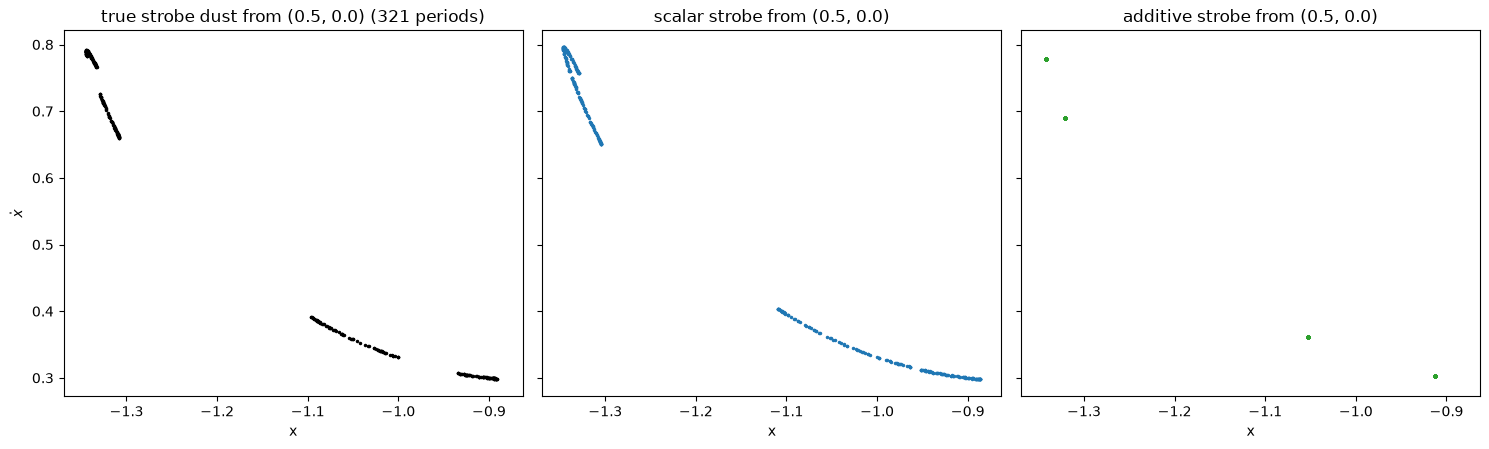

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True, sharey=True)
ax[0].plot(chaos_sp[:, 0], chaos_sp[:, 1], '.', color='k', ms=3)
ax[0].set_title(f'true strobe dust from {SECOND_IC}'
                f' ({len(chaos_sp)} periods)')
for a, (tag, rhs, p, color) in zip(ax[1:], MODELS):
    _, lsp_all = strobe_run(lambda s, t: rhs(p, s, t), SECOND_IC,
                            N_SETTLE + N_MEAS * 4, 1)
    lsp = lsp_all[N_SETTLE:]
    a.plot(lsp[:, 0], lsp[:, 1], '.', color=color, ms=3)
    a.set_title(f'{tag} strobe from {SECOND_IC}')
    spread = lsp.std(axis=0)
    print(f'[{tag}] strobe cloud std: x {spread[0]:.3f}  v {spread[1]:.3f}'
          f'   (true: x {chaos_sp.std(axis=0)[0]:.3f}'
          f'  v {chaos_sp.std(axis=0)[1]:.3f})')
for a in ax:
    a.set_xlabel('x')
ax[0].set_ylabel(r'$\dot{x}$')
plt.tight_layout(); plt.show()

## 8 — The learned forces, term by term

Gauge-fixed as in Steps 4–5: $g$ shifted to zero mean over the drive cycle, $d$
shifted so $d(0) = 0$, both shifts absorbed into $f$.

gauge constants:  mean(g) = -0.0674   d(0) = -0.1645   (moved into f)


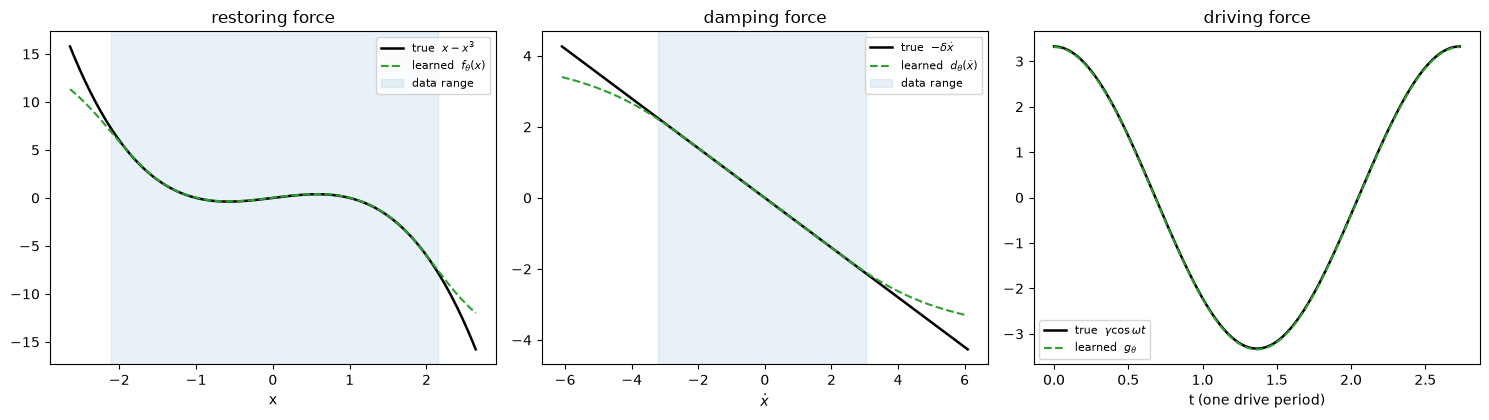

max |f error|   in data range 3.29e-01   at edges of plot: 4.45e+00
max |d error|   in data range 2.50e-02
max |g error|   2.01e-02


In [12]:
term_f = jax.vmap(lambda x: additive_terms(params_a,
                  jnp.array([x, 0.0]), 0.0)[0])
term_d = jax.vmap(lambda v: additive_terms(params_a,
                  jnp.array([0.0, v]), 0.0)[1])

t_cycle = np.linspace(0.0, T_DRIVE, 200)
term_g = jax.vmap(lambda t: additive_terms(params_a,
                  jnp.array([0.0, 0.0]), t)[2])

g_vals = np.asarray(term_g(jnp.asarray(t_cycle)))
c_g = g_vals.mean()
c_d = float(term_d(jnp.array([0.0]))[0])
print(f'gauge constants:  mean(g) = {c_g:+.4f}   d(0) = {c_d:+.4f}'
      f'   (moved into f)')

x_plot = np.linspace(-1.5 * EXT_X, 1.5 * EXT_X, 400)
v_plot = np.linspace(-2.5 * EXT_V, 2.5 * EXT_V, 400)
f_vals = np.asarray(term_f(jnp.asarray(x_plot))) + c_g + c_d
d_vals = np.asarray(term_d(jnp.asarray(v_plot))) - c_d
g_tilde = g_vals - c_g

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
a = ax[0]
a.plot(x_plot, x_plot - x_plot**3, 'k', lw=1.8, label='true  $x - x^3$')
a.plot(x_plot, f_vals, '--', color='tab:green', lw=1.5,
       label=r'learned  $f_\theta(x)$')
a.axvspan(pts[:, 0].min(), pts[:, 0].max(), color='tab:blue', alpha=0.10,
          label='data range')
a.set_xlabel('x'); a.set_title('restoring force')
a.legend(fontsize=8)

a = ax[1]
a.plot(v_plot, -DELTA * v_plot, 'k', lw=1.8,
       label=r'true  $-\delta\dot{x}$')
a.plot(v_plot, d_vals, '--', color='tab:green', lw=1.5,
       label=r'learned  $d_\theta(\dot{x})$')
a.axvspan(pts[:, 1].min(), pts[:, 1].max(), color='tab:blue', alpha=0.10,
          label='data range')
a.set_xlabel(r'$\dot{x}$'); a.set_title('damping force')
a.legend(fontsize=8)

a = ax[2]
a.plot(t_cycle, GAMMA * np.cos(OMEGA * t_cycle), 'k', lw=1.8,
       label=r'true  $\gamma\cos\omega t$')
a.plot(t_cycle, g_tilde, '--', color='tab:green', lw=1.5,
       label=r'learned  $g_\theta$')
a.set_xlabel('t (one drive period)'); a.set_title('driving force')
a.legend(fontsize=8)
plt.tight_layout(); plt.show()

in_x = (x_plot > pts[:, 0].min()) & (x_plot < pts[:, 0].max())
in_v = (v_plot > pts[:, 1].min()) & (v_plot < pts[:, 1].max())
f_err = np.abs(f_vals - (x_plot - x_plot**3))
print(f'max |f error|   in data range {f_err[in_x].max():.2e}'
      f'   at edges of plot: {f_err[[0, -1]].max():.2e}')
print(f'max |d error|   in data range {np.abs(d_vals + DELTA * v_plot)[in_v].max():.2e}')
print(f'max |g error|   {np.abs(g_tilde - GAMMA * np.cos(OMEGA * t_cycle)).max():.2e}')

## What this rung settles

Read off the results above:

1. **Rollout accuracy with a chaotic attractor in the mix**: ICs that land in the
   chaotic set have a positive Lyapunov exponent ($\approx +0.05\,/\mathrm{s}$), so
   even a near-perfect model must drift from the truth at late times — 20 s
   ($\approx 1$ e-fold) keeps the comparison meaningful, but chaotic-basin rows in
   the tables should read softer than P3-basin rows for *any* model.
2. **The learned strobe table from the P3 IC** is the clean pass/fail: residual dips
   at $m = 3$ or the model has changed the attractor.
3. **The chaotic-IC long run** is the statistical test: the learned trajectory cannot
   track the true one forever, but its strobe cloud should stay *dust* filling the
   same region — if it collapses to a few points, the model has killed the chaos.

Companion notebook: `duffing_node_p8.ipynb` — the freshly-doubled period-8 regime.